[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/brilliantbeaver/alexpose/blob/main/penny/gavd3/06_capstone_health_condition_classifiers.ipynb)

# 06. Capstone descriptive classifiers and leakage audit

Freeze the final staged target encoder, fit Random Forest readouts, and make representation-training exposure impossible to mistake for held-out generalization.

**Research use only.** This tutorial does not diagnose a person or validate a clinical device.

**Important:** the revised final encoder was fine-tuned with condition labels on the curriculum corpus. Unless notebook 04 is rerun inside each outer training fold, classifier scores on those rows are transductive, label-informed descriptions:not test performance.


In [1]:
from pathlib import Path
import os
import sys
import subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/brilliantbeaver/alexpose.git"

if IN_COLAB:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "numpy", "pandas", "scipy", "scikit-learn", "matplotlib",
        "seaborn", "torch", "tqdm", "python-dotenv", "yt-dlp[default]",
        "opencv-python-headless", "mediapipe<1", "joblib", "pyarrow",
    ])
    clone_dir = Path("/content/alexpose")
    if not (clone_dir / ".git").exists():
        subprocess.check_call(["git", "clone", "--depth", "1", REPO_URL, str(clone_dir)])
    os.chdir(clone_dir)


def find_project_root(start=None):
    env_root = os.getenv("ALEXPOSE_ROOT")
    if env_root:
        candidate = Path(env_root).expanduser().resolve()
        if (candidate / ".git").exists() and (candidate / "data" / "gavd").exists():
            return candidate
        print(f"Ignoring invalid ALEXPOSE_ROOT: {candidate}")
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / ".git").exists() and (candidate / "data" / "gavd").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root()
TUTORIAL_DIR = PROJECT_ROOT / "experiments" / "sjepa" / "gavd5-drift"

try:
    from dotenv import load_dotenv
    load_dotenv(TUTORIAL_DIR / ".env", override=False)
    load_dotenv(PROJECT_ROOT / ".env", override=False)
except Exception:
    pass

MODE = os.getenv("GAVD_MODE", "smoke").strip().lower()
if MODE not in {"smoke", "real"}:
    raise ValueError("GAVD_MODE must be smoke or real")
if MODE == "smoke":
    print(
        "SMOKE MODE: hand-authored motions test code paths only. "
        "They have no pathophysiological or clinical validity."
    )

PREFERRED_ROOT = Path(
    os.getenv(
        "GAVD4_ROOT",
        "/Users/pmui/vaults/worldmodels/gait/skeleton-jepa/gavd4",
    )
).expanduser()

requested_data = os.getenv("GAVD4_DATA_DIR") or os.getenv("GAVD_DATA_GAVD_DIR")
if requested_data and Path(requested_data).expanduser().exists():
    DATA_GAVD_DIR = Path(requested_data).expanduser()
elif requested_data:
    print(f"Ignoring missing GAVD CSV path: {Path(requested_data).expanduser()}")
    if (TUTORIAL_DIR / "data-gavd").exists():
        DATA_GAVD_DIR = TUTORIAL_DIR / "data-gavd"
    elif (PREFERRED_ROOT / "data-gavd").exists():
        DATA_GAVD_DIR = PREFERRED_ROOT / "data-gavd"
    else:
        DATA_GAVD_DIR = PROJECT_ROOT / "data" / "gavd"
elif (TUTORIAL_DIR / "data-gavd").exists():
    DATA_GAVD_DIR = TUTORIAL_DIR / "data-gavd"
elif (PREFERRED_ROOT / "data-gavd").exists():
    DATA_GAVD_DIR = PREFERRED_ROOT / "data-gavd"
else:
    DATA_GAVD_DIR = PROJECT_ROOT / "data" / "gavd"

requested_youtube = os.getenv("GAVD4_YOUTUBE_DIR") or os.getenv("GAVD_YOUTUBE_DIR")
if requested_youtube:
    YOUTUBE_DIR = Path(requested_youtube).expanduser()
elif PREFERRED_ROOT.exists():
    YOUTUBE_DIR = PREFERRED_ROOT / "youtube"
else:
    YOUTUBE_DIR = PROJECT_ROOT / "experiments" / "sjepa" / "gavd5-drift" / "work" / "youtube"

CACHE_DIR = Path(
    os.getenv("GAVD_CACHE_DIR", TUTORIAL_DIR / "work" / "cache")
).expanduser()
ARTIFACT_ROOT = Path(
    os.getenv("GAVD_ARTIFACT_DIR", TUTORIAL_DIR / "work" / "artifacts")
).expanduser()
ARTIFACT_DIR = ARTIFACT_ROOT / MODE
POSE_DIR = ARTIFACT_DIR / "poses"

# ---------------------------------------------------------------------------
# Optional augmentation-normal cohort (opt-in; default OFF).
#
# The self-annotated data-videos/normal clips are pose-extracted by
# notes/extract_augmented_poses.py into a SEPARATE pose folder and pretrained
# into a SEPARATE checkpoint by notebook 04. This flag surfaces that cohort in
# an ADDITIVE "Lane C" only. When it is off (the default), every locked
# canonical lane (A1/A2/binary/leakage and their 642/94 census; 47/21 and shared==9
# asserts) keeps the same canonical sequence rows. The flag selects the matching
# final encoder variant for every lane. When it is on, the canonical
# arrays still stay canonical-only; the augmentation cohort is carried in
# separate parallel arrays so the canonical numbers never move.
#
# Truthy set matches notebook 04 exactly: {"1","true","yes","on"}.
# ---------------------------------------------------------------------------
INCLUDE_AUGMENTED_NORMAL = os.getenv(
    "SJEPA_INCLUDE_AUGMENTED_NORMAL", "0"
).strip().lower() in {"1", "true", "yes", "on"}
AUGMENTED_POSE_DIR = ARTIFACT_DIR / "poses_augmented"
AUGMENTED_REPORT = ARTIFACT_DIR / "augmented_pose_extraction_report.csv"
MIN_AUGMENTED_NEURO_OBSERVED = 0.45
# Notebook 04 writes an augmentation-broadened encoder to a distinct file so
# the canonical checkpoint is never overwritten. The downstream selector
# requires the variant requested by the flag and never silently falls back.
CANONICAL_CHECKPOINT = ARTIFACT_DIR / "sjepa_curriculum_final.pt"
AUGMENTED_CHECKPOINT = ARTIFACT_DIR / "sjepa_curriculum_final_augmented.pt"

for folder in [CACHE_DIR, ARTIFACT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

os.environ.setdefault("MPLCONFIGDIR", str(CACHE_DIR / "matplotlib"))
os.environ.setdefault("XDG_CACHE_HOME", str(CACHE_DIR / "xdg-cache"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
Path(os.environ["XDG_CACHE_HOME"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
from IPython.display import SVG, display


def show_tutorial_svg(filename):
    '''Render a repository SVG reliably in local Jupyter and Colab.'''
    path = TUTORIAL_DIR / "images" / filename
    if not path.exists():
        raise FileNotFoundError(
            f"Missing tutorial figure {path}. Clone the full alexpose repository."
        )
    display(SVG(filename=str(path)))

print(f"mode: {MODE}")
print(f"project: {PROJECT_ROOT}")
print(f"GAVD CSVs: {DATA_GAVD_DIR}")
print(f"YouTube cache: {YOUTUBE_DIR}")
print(f"artifacts: {ARTIFACT_DIR}")
print(
    "augmentation-normal cohort: "
    + ("ENABLED (Lane C additive)" if INCLUDE_AUGMENTED_NORMAL else "disabled")
)


mode: real
project: /Users/pmui/dev/alexpose
GAVD CSVs: /Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/data-gavd
YouTube cache: /Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/work/youtube
artifacts: /Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/work/artifacts/real
augmentation-normal cohort: disabled


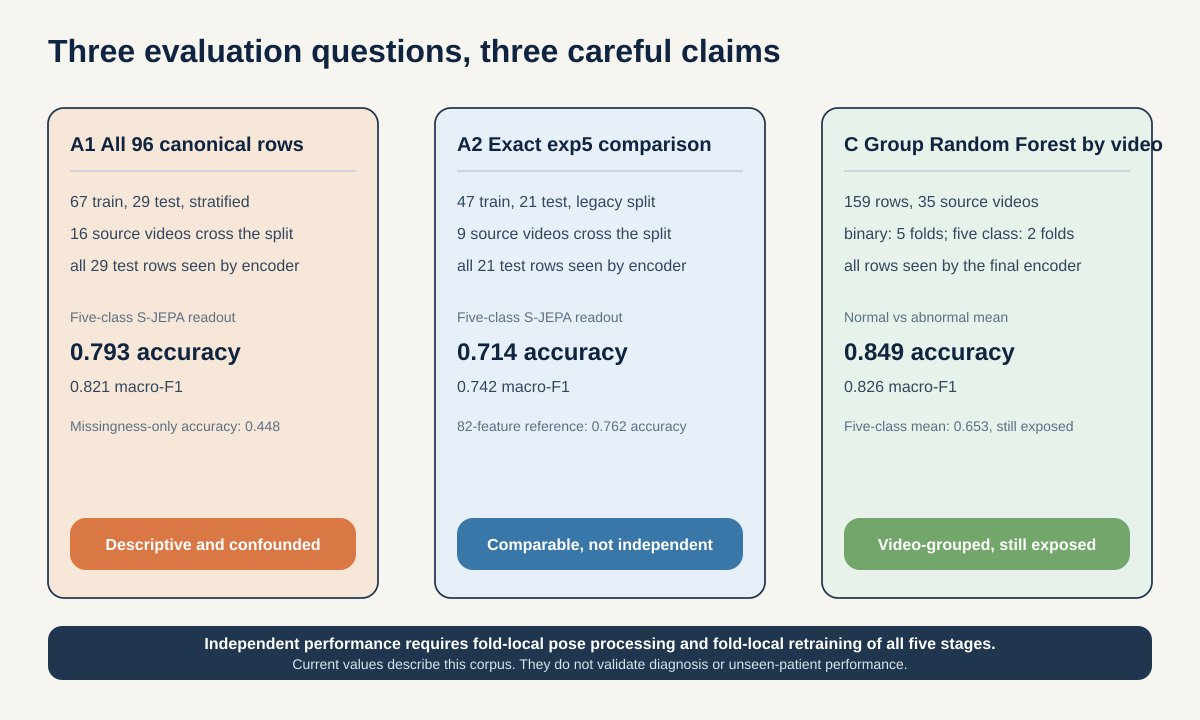

In [2]:
show_tutorial_svg("08_evaluation_protocol.svg")


In [3]:
BLAZEPOSE_33 = [
    "NOSE", "LEFT_EYE_INNER", "LEFT_EYE", "LEFT_EYE_OUTER",
    "RIGHT_EYE_INNER", "RIGHT_EYE", "RIGHT_EYE_OUTER", "LEFT_EAR",
    "RIGHT_EAR", "MOUTH_LEFT", "MOUTH_RIGHT", "LEFT_SHOULDER",
    "RIGHT_SHOULDER", "LEFT_ELBOW", "RIGHT_ELBOW", "LEFT_WRIST",
    "RIGHT_WRIST", "LEFT_PINKY", "RIGHT_PINKY", "LEFT_INDEX",
    "RIGHT_INDEX", "LEFT_THUMB", "RIGHT_THUMB", "LEFT_HIP",
    "RIGHT_HIP", "LEFT_KNEE", "RIGHT_KNEE", "LEFT_ANKLE",
    "RIGHT_ANKLE", "LEFT_HEEL", "RIGHT_HEEL", "LEFT_FOOT_INDEX",
    "RIGHT_FOOT_INDEX",
]
MASK_KEYPOINTS = [11, 12, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
MASK_KEYPOINT_NAMES = [
    "LEFT_SHOULDER", "RIGHT_SHOULDER", "LEFT_HIP", "RIGHT_HIP",
    "LEFT_KNEE", "RIGHT_KNEE", "LEFT_ANKLE", "RIGHT_ANKLE",
    "LEFT_HEEL", "RIGHT_HEEL", "LEFT_FOOT_INDEX", "RIGHT_FOOT_INDEX",
]
assert MASK_KEYPOINTS == sorted(set(MASK_KEYPOINTS))
assert [BLAZEPOSE_33[i] for i in MASK_KEYPOINTS] == MASK_KEYPOINT_NAMES


In [4]:
CONDITIONS = ["normal", "parkinsons", "stroke", "myopathic", "cerebralpalsy"]


In [5]:
def synthetic_gait_sequence(condition="normal", frames=64, seed=0):
    '''Create a code-path fixture, not a physiological disease simulation.'''
    rng = np.random.default_rng(seed)
    phase = np.linspace(0.0, 4.0 * np.pi, frames, endpoint=False)
    seq = np.zeros((frames, 33, 4), dtype=np.float32)
    seq[..., 3] = 1.0
    base = {
        11: (0.42, 0.28), 12: (0.58, 0.28),
        23: (0.45, 0.52), 24: (0.55, 0.52),
        25: (0.44, 0.70), 26: (0.56, 0.70),
        27: (0.43, 0.89), 28: (0.57, 0.89),
        29: (0.42, 0.92), 30: (0.58, 0.92),
        31: (0.39, 0.94), 32: (0.61, 0.94),
    }
    for joint, (x, y) in base.items():
        seq[:, joint, 0] = x
        seq[:, joint, 1] = y
    amplitude = 0.045
    lift = 0.025
    if condition == "parkinsons":
        amplitude *= 0.45
        lift *= 0.45
    if condition == "myopathic":
        seq[:, [11, 12], 0] += 0.03 * np.sin(phase)[:, None]
        seq[:, [23, 24], 0] += 0.018 * np.sin(phase)[:, None]
    for joint, knee, foot, offset in [(27, 25, 31, 0.0), (28, 26, 32, np.pi)]:
        wave = np.sin(phase + offset)
        if condition == "stroke" and joint == 27:
            wave = 0.35 * wave
        if condition == "cerebralpalsy":
            seq[:, knee, 1] -= 0.045
            seq[:, joint, 1] -= 0.02
        seq[:, joint, 0] += amplitude * wave
        seq[:, knee, 0] += 0.4 * amplitude * wave
        seq[:, foot, 0] += amplitude * wave
        seq[:, joint, 1] -= lift * np.maximum(wave, 0.0)
        seq[:, foot, 1] -= 0.7 * lift * np.maximum(wave, 0.0)
    seq[..., :3] += rng.normal(0.0, 0.0025, seq[..., :3].shape)
    return seq


def synthetic_corpus(conditions=None, n_per_condition=10, frames=64, seed=42):
    if conditions is None:
        conditions = [
            "normal", "parkinsons", "stroke", "myopathic", "cerebralpalsy"
        ]
    records = []
    counter = 0
    for condition in conditions:
        for sample in range(n_per_condition):
            records.append({
                "condition": condition,
                "sequence_id": f"smoke_{condition}_{sample:03d}",
                "video_id": f"smoke_video_{condition}_{sample // 2:02d}",
                "sequence": synthetic_gait_sequence(
                    condition=condition,
                    frames=frames,
                    seed=seed + counter,
                ),
            })
            counter += 1
    return records


In [6]:
def interpolate_low_visibility(sequence, threshold=0.45, max_gap=4):
    '''Fill only short internal gaps and preserve the original validity mask.

    Long gaps and sequence ends are never extrapolated. Their coordinates remain
    missing until center_and_scale converts them to an explicit zero sentinel.
    They can never become S-JEPA prediction targets.
    '''
    sequence = np.asarray(sequence, dtype=np.float32).copy()
    if sequence.ndim != 3 or sequence.shape[1:] != (33, 4):
        raise ValueError(f"Expected [T, 33, 4], received {sequence.shape}")
    visibility = np.nan_to_num(sequence[..., 3], nan=0.0)
    finite = np.isfinite(sequence[..., :3]).all(axis=-1)
    valid = (visibility >= threshold) & finite
    filled = valid.copy()
    for joint in range(33):
        observed = np.flatnonzero(valid[:, joint])
        for left, right in zip(observed[:-1], observed[1:]):
            gap = int(right - left - 1)
            if not 0 < gap <= max_gap:
                continue
            fraction = (
                np.arange(1, gap + 1, dtype=np.float32) / (gap + 1)
            )[:, None]
            sequence[left + 1:right, joint, :3] = (
                sequence[left, joint, :3][None, :] * (1.0 - fraction)
                + sequence[right, joint, :3][None, :] * fraction
            )
            filled[left + 1:right, joint] = True
        sequence[~filled[:, joint], joint, :3] = np.nan
    sequence[..., 3] = visibility
    return sequence, valid


def center_and_scale(sequence, eps=1e-6):
    sequence = np.asarray(sequence, dtype=np.float32).copy()
    xyz = sequence[..., :3]
    left_hip, right_hip = xyz[:, 23], xyz[:, 24]
    left_ok = np.isfinite(left_hip).all(axis=1)
    right_ok = np.isfinite(right_hip).all(axis=1)
    pelvis = np.full((len(xyz), 3), np.nan, dtype=np.float32)
    pelvis[left_ok & right_ok] = 0.5 * (
        left_hip[left_ok & right_ok] + right_hip[left_ok & right_ok]
    )
    pelvis[left_ok & ~right_ok] = left_hip[left_ok & ~right_ok]
    pelvis[right_ok & ~left_ok] = right_hip[right_ok & ~left_ok]
    pelvis_ok = np.isfinite(pelvis).all(axis=1)
    fallback = np.median(pelvis[pelvis_ok], axis=0) if pelvis_ok.any() else np.zeros(3)
    pelvis[~np.isfinite(pelvis).all(axis=1)] = fallback
    xyz = xyz - pelvis[:, None, :]
    shoulder_width = np.linalg.norm(xyz[:, 11, :2] - xyz[:, 12, :2], axis=-1)
    hip_width = np.linalg.norm(xyz[:, 23, :2] - xyz[:, 24, :2], axis=-1)
    body_scale = np.nanmedian(np.maximum(shoulder_width, hip_width))
    if not np.isfinite(body_scale) or body_scale < eps:
        body_scale = 1.0
    sequence[..., :3] = np.nan_to_num(
        xyz / body_scale, nan=0.0, posinf=0.0, neginf=0.0
    )
    return np.nan_to_num(sequence, nan=0.0, posinf=0.0, neginf=0.0)


def temporal_resize(array, frames):
    array = np.asarray(array)
    if len(array) == frames:
        return array.copy()
    if len(array) < 2:
        return np.repeat(array, frames, axis=0)
    old_t = np.linspace(0.0, 1.0, len(array))
    new_t = np.linspace(0.0, 1.0, frames)
    flat = array.reshape(len(array), -1)
    resized = np.stack(
        [np.interp(new_t, old_t, flat[:, i]) for i in range(flat.shape[1])],
        axis=1,
    )
    return resized.reshape(frames, *array.shape[1:]).astype(array.dtype)


def prepare_sequence(
    sequence,
    frames=64,
    visibility_threshold=0.45,
    max_gap=4,
):
    cleaned, valid = interpolate_low_visibility(
        sequence, visibility_threshold, max_gap=max_gap
    )
    cleaned = center_and_scale(cleaned)
    cleaned = temporal_resize(cleaned, frames)
    valid = temporal_resize(valid.astype(np.float32), frames) >= 0.5
    return cleaned[..., :3].astype(np.float32), valid.astype(bool)


In [7]:
import copy
import math
import torch
from torch import nn


class SkeletonPatchEncoder(nn.Module):
    def __init__(
        self,
        frames=64,
        joints=33,
        coordinate_dim=3,
        segment_length=4,
        embed_dim=64,
        depth=2,
        heads=4,
        dropout=0.0,
    ):
        super().__init__()
        if frames % segment_length:
            raise ValueError("frames must be divisible by segment_length")
        self.frames = frames
        self.joints = joints
        self.coordinate_dim = coordinate_dim
        self.segment_length = segment_length
        self.segments = frames // segment_length
        self.embed_dim = embed_dim
        self.patch_embed = nn.Linear(segment_length * coordinate_dim, embed_dim)
        self.time_pos = nn.Parameter(torch.randn(self.segments, embed_dim) * 0.02)
        self.joint_pos = nn.Parameter(torch.randn(joints, embed_dim) * 0.02)
        layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=heads,
            dim_feedforward=embed_dim * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
        self.norm = nn.LayerNorm(embed_dim)

    def patchify(self, x):
        batch, frames, joints, channels = x.shape
        expected = (self.frames, self.joints, self.coordinate_dim)
        if (frames, joints, channels) != expected:
            raise ValueError(f"Expected [B, {expected}], received {x.shape}")
        patches = x.reshape(
            batch, self.segments, self.segment_length, joints, channels
        )
        patches = patches.permute(0, 1, 3, 2, 4).contiguous()
        return patches.flatten(3)

    def positioned_tokens(self, x):
        tokens = self.patch_embed(self.patchify(x))
        return (
            tokens
            + self.time_pos[None, :, None, :]
            + self.joint_pos[None, None, :, :]
        )

    def forward(self, x, keep_mask=None):
        tokens = self.positioned_tokens(x)
        batch = len(tokens)
        flat = tokens.reshape(batch, self.segments * self.joints, self.embed_dim)
        if keep_mask is not None:
            keep_mask = keep_mask.reshape(batch, -1)
            kept_per_sample = keep_mask.sum(dim=1)
            if not torch.equal(kept_per_sample, kept_per_sample[:1].expand_as(kept_per_sample)):
                raise ValueError("Each sample must keep the same number of tokens")
            flat = flat[keep_mask].reshape(batch, int(kept_per_sample[0]), self.embed_dim)
        return self.norm(self.blocks(flat))


class SkeletonPredictor(nn.Module):
    def __init__(
        self,
        segments,
        joints,
        encoder_dim=64,
        predictor_dim=64,
        depth=2,
        heads=4,
        dropout=0.0,
    ):
        super().__init__()
        self.segments = segments
        self.joints = joints
        self.encoder_to_predictor = nn.Linear(encoder_dim, predictor_dim)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, predictor_dim))
        nn.init.normal_(self.mask_token, std=0.02)
        self.time_pos = nn.Parameter(torch.randn(segments, predictor_dim) * 0.02)
        self.joint_pos = nn.Parameter(torch.randn(joints, predictor_dim) * 0.02)
        layer = nn.TransformerEncoderLayer(
            d_model=predictor_dim,
            nhead=heads,
            dim_feedforward=predictor_dim * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
        self.norm = nn.LayerNorm(predictor_dim)
        self.output = nn.Linear(predictor_dim, encoder_dim)

    def forward(self, visible_features, target_mask):
        batch = len(visible_features)
        target_mask = target_mask.reshape(batch, self.segments * self.joints)
        visible_mask = ~target_mask
        visible = self.encoder_to_predictor(visible_features)
        full = self.mask_token.expand(
            batch, self.segments * self.joints, -1
        ).clone()
        full[visible_mask] = visible.reshape(-1, visible.shape[-1])
        positions = (
            self.time_pos[:, None, :] + self.joint_pos[None, :, :]
        ).reshape(1, self.segments * self.joints, -1)
        full = full + positions
        predicted = self.output(self.norm(self.blocks(full)))
        return predicted[target_mask].reshape(batch, -1, predicted.shape[-1])


class SJEPAGait(nn.Module):
    def __init__(
        self,
        frames=64,
        joints=33,
        coordinate_dim=3,
        segment_length=4,
        embed_dim=64,
        encoder_depth=2,
        predictor_depth=2,
        heads=4,
    ):
        super().__init__()
        self.view_encoder = SkeletonPatchEncoder(
            frames, joints, coordinate_dim, segment_length,
            embed_dim, encoder_depth, heads,
        )
        self.target_encoder = copy.deepcopy(self.view_encoder)
        for parameter in self.target_encoder.parameters():
            parameter.requires_grad_(False)
        self.predictor = SkeletonPredictor(
            self.view_encoder.segments,
            joints,
            embed_dim,
            embed_dim,
            predictor_depth,
            heads,
        )
        self.register_buffer("target_center", torch.zeros(embed_dim))

    def forward(self, view, target, target_mask):
        visible_features = self.view_encoder(view, keep_mask=~target_mask)
        predicted = self.predictor(visible_features, target_mask)
        with torch.no_grad():
            all_targets = self.target_encoder(target)
            flat_mask = target_mask.reshape(len(target), -1)
            selected = all_targets[flat_mask].reshape(
                len(target), -1, all_targets.shape[-1]
            )
        return predicted, selected

    @torch.no_grad()
    def update_target(self, momentum):
        for target_parameter, view_parameter in zip(
            self.target_encoder.parameters(), self.view_encoder.parameters()
        ):
            target_parameter.mul_(momentum).add_(
                view_parameter, alpha=1.0 - momentum
            )

    @torch.no_grad()
    def update_center(self, targets, beta=0.9):
        batch_center = targets.mean(dim=(0, 1))
        self.target_center.mul_(beta).add_(batch_center, alpha=1.0 - beta)


def sjepa_cross_entropy(
    predicted,
    targets,
    center,
    predictor_temperature=0.10,
    target_temperature=0.06,
):
    target_prob = torch.softmax(
        (targets - center[None, None, :]) / target_temperature,
        dim=-1,
    ).detach()
    prediction_log_prob = torch.log_softmax(
        predicted / predictor_temperature,
        dim=-1,
    )
    return -(target_prob * prediction_log_prob).sum(dim=-1).mean()


def cosine_ema(step, total_steps, start=0.996, end=1.0):
    progress = min(max(step / max(total_steps - 1, 1), 0.0), 1.0)
    return end - (end - start) * (math.cos(math.pi * progress) + 1.0) / 2.0


LEFT_RIGHT_PAIRS = [
    (1, 4), (2, 5), (3, 6), (7, 8), (9, 10), (11, 12),
    (13, 14), (15, 16), (17, 18), (19, 20), (21, 22),
    (23, 24), (25, 26), (27, 28), (29, 30), (31, 32),
]


def geometric_view(
    x,
    max_degrees=8.0,
    translate=0.03,
    flip_probability=0.0,
):
    """Apply one sequence-wide transform per sample.

    Rotation is around the relative vertical y axis, so x and z are mixed.
    Flip defaults to off because laterality can matter for stroke. If enabled,
    coordinates are reflected and every left-right landmark pair is swapped.
    """
    view = x.clone()
    present = view.abs().sum(dim=-1) > 1e-8
    batch = len(view)
    angles = (
        torch.rand(batch, device=x.device) * 2.0 - 1.0
    ) * math.radians(max_degrees)
    cosine, sine = torch.cos(angles), torch.sin(angles)
    original_x = view[..., 0].clone()
    original_z = view[..., 2].clone()
    rotated_x = cosine[:, None, None] * original_x + sine[:, None, None] * original_z
    rotated_z = -sine[:, None, None] * original_x + cosine[:, None, None] * original_z
    view[..., 0] = rotated_x
    view[..., 2] = rotated_z
    offsets = (torch.rand(batch, 1, 1, 2, device=x.device) * 2.0 - 1.0) * translate
    view[..., :2] += offsets
    if flip_probability > 0:
        flip = torch.rand(batch, device=x.device) < flip_probability
        for batch_index in torch.where(flip)[0].tolist():
            view[batch_index, ..., 0] *= -1.0
            original = view[batch_index].clone()
            original_present = present[batch_index].clone()
            for left, right in LEFT_RIGHT_PAIRS:
                view[batch_index, :, left] = original[:, right]
                view[batch_index, :, right] = original[:, left]
                present[batch_index, :, left] = original_present[:, right]
                present[batch_index, :, right] = original_present[:, left]
    view = view.masked_fill(~present[..., None], 0.0)
    return view


In [8]:
def pose_records_from_cache(pose_dir=POSE_DIR, conditions=CONDITIONS):
    records = []
    for condition in conditions:
        folder = Path(pose_dir) / condition
        for path in sorted(folder.glob("*.npz")):
            data = np.load(path, allow_pickle=False)
            required = {
                "sequence", "sequence_id", "video_id", "condition",
                "frame_numbers", "crop_bounds", "fps", "source_csv",
                "source_video", "pose_model", "pose_model_sha256",
                "extraction_version",
            }
            missing = required.difference(data.files)
            if missing:
                raise ValueError(
                    f"Stale pose cache {path} is missing {sorted(missing)}. "
                    "Re-extract it with notebook 02."
                )
            sequence = data["sequence"].astype(np.float32)
            if sequence.ndim != 3 or sequence.shape[1:] != (33, 4):
                raise ValueError(f"Bad pose shape in {path}: {sequence.shape}")
            stored_condition = str(data["condition"].item())
            if stored_condition != condition:
                raise ValueError(
                    f"Pose condition {stored_condition} does not match folder {condition}"
                )
            if len(data["frame_numbers"]) != len(sequence):
                raise ValueError(f"Frame and pose lengths differ in {path}")
            records.append({
                "condition": condition,
                "sequence_id": str(data["sequence_id"].item()),
                "video_id": str(data["video_id"].item()),
                "source_video": str(data["source_video"].item()),
                "fps": float(data["fps"].item()),
                "extraction_version": str(data["extraction_version"].item()),
                "pose_model_sha256": str(data["pose_model_sha256"].item()),
                "sequence": sequence,
                "path": str(path),
            })
    return records


def load_records_for_mode(conditions=CONDITIONS, smoke_per_condition=10, frames=64):
    if MODE == "smoke":
        records = synthetic_corpus(
            conditions=conditions,
            n_per_condition=smoke_per_condition,
            frames=frames,
        )
        print(f"Explicit smoke corpus: {len(records)} synthetic sequences")
        return records
    records = pose_records_from_cache(conditions=conditions)
    counts = pd.Series([r["condition"] for r in records]).value_counts()
    missing = [condition for condition in conditions if counts.get(condition, 0) == 0]
    if missing:
        raise FileNotFoundError(
            f"Real mode requires cached pose sequences for {missing}. "
            "Run notebook 02 first."
        )
    print(f"Real pose corpus: {len(records)} sequences")
    return records


def augmented_normal_records(pose_dir=AUGMENTED_POSE_DIR):
    """Load the self-annotated augmentation-normal cohort as a separate pool.

    These sequences live under a distinct pose folder written by
    notes/extract_augmented_poses.py. Their bounding boxes are auto-detected
    from MediaPipe Pose (bbox_source == "mediapipe_pose_auto"), not curated
    GAVD annotations, so they are always kept apart from the full 642/94
    canonical corpus and only ever join an additive Lane C. Every canonical
    npz key is still validated; the extra provenance keys (cohort, clip_id,
    bbox_source) are tolerated.
    """
    if not INCLUDE_AUGMENTED_NORMAL or MODE != "real":
        return []
    folder = Path(pose_dir) / "normal"
    if not folder.exists():
        raise FileNotFoundError(
            f"SJEPA_INCLUDE_AUGMENTED_NORMAL is set but {folder} is missing."
        )
    if not AUGMENTED_REPORT.is_file():
        raise FileNotFoundError(
            f"Missing augmentation selection contract: {AUGMENTED_REPORT}"
        )
    report = pd.read_csv(AUGMENTED_REPORT)
    required_report = {"sequence_id", "status", "neuro_observed"}
    missing_report = required_report.difference(report.columns)
    if missing_report:
        raise ValueError(
            f"Augmentation report missing {sorted(missing_report)}"
        )
    candidates = report[
        ~report["status"].astype(str).str.startswith("error")
    ].copy()
    candidates["accepted"] = (
        pd.to_numeric(candidates["neuro_observed"], errors="coerce")
        >= MIN_AUGMENTED_NEURO_OBSERVED
    )
    selected_ids = set(
        candidates.loc[candidates["accepted"], "sequence_id"].astype(str)
    )
    available = {path.stem: path for path in folder.glob("*.npz")}
    missing_selected = sorted(selected_ids.difference(available))
    if missing_selected:
        raise FileNotFoundError(
            f"Accepted augmented pose files are missing: {missing_selected}"
        )
    records = []
    for sequence_id in sorted(selected_ids):
        path = available[sequence_id]
        data = np.load(path, allow_pickle=False)
        required = {
            "sequence", "sequence_id", "video_id", "condition",
            "frame_numbers", "crop_bounds", "fps", "source_csv",
            "source_video", "pose_model", "pose_model_sha256",
            "extraction_version",
        }
        missing = required.difference(data.files)
        if missing:
            raise ValueError(
                f"Stale augmented pose cache {path} is missing {sorted(missing)}. "
                "Re-extract it with notes/extract_augmented_poses.py."
            )
        sequence = data["sequence"].astype(np.float32)
        if sequence.ndim != 3 or sequence.shape[1:] != (33, 4):
            raise ValueError(f"Bad pose shape in {path}: {sequence.shape}")
        if str(data["condition"].item()) != "normal":
            raise ValueError(
                f"Augmentation cohort must be normal; {path} is "
                f"{data['condition'].item()}"
            )
        if len(data["frame_numbers"]) != len(sequence):
            raise ValueError(f"Frame and pose lengths differ in {path}")
        records.append({
            "condition": "normal",
            "sequence_id": str(data["sequence_id"].item()),
            "video_id": str(data["video_id"].item()),
            "source_video": str(data["source_video"].item()),
            "fps": float(data["fps"].item()),
            "extraction_version": str(data["extraction_version"].item()),
            "pose_model_sha256": str(data["pose_model_sha256"].item()),
            "cohort": (
                str(data["cohort"].item())
                if "cohort" in data.files
                else "augmented_normal"
            ),
            "bbox_source": (
                str(data["bbox_source"].item())
                if "bbox_source" in data.files
                else "mediapipe_pose_auto"
            ),
            "sequence": sequence,
            "path": str(path),
        })
    return records


In [9]:
EXP5_ORDER = [
    "cljvvsucg00043n6l4evgn7q4", "cljr5jk0h000n3n6la34mkdfz",
    "cljo8eumx00683n6le2s7myd4", "cljr5fc5d000b3n6lkvc71zyl",
    "cljr5iki0000j3n6lwi8z5nh6", "cljo8cyv500603n6lyl148tmg",
    "cljo8g74m006g3n6l6kuxy9cf", "cljo8hcfv006k3n6lgrx0fcpx",
    "cljo8fdke006c3n6lr8bzjjgi", "cljo8c0sw005w3n6l9ulr2eg2",
    "cljo8e32t00643n6l37ncjeic", "cljr5hwxc000f3n6lof5w9tyt",
    "cljarhldg00d13n6l7utw0lqn", "cljo83yl800513n6lfglf5jn8",
    "cljawdoej000d3n6ll5ysj34f", "cljarmcm700dh3n6lxw24hxgx",
    "cljaxabfg003a3n6l95mrlcry", "cljarj6rf00d53n6ljtivf4q7",
    "cljarlbch00dd3n6l9jaubrxq", "cljarp08600dt3n6lxa7sysiv",
    "cljarpts600dx3n6l98zqf6yn", "cljaroguw00dp3n6lhfddiadu",
    "cljargosy00cx3n6lm6atozrz", "cljarn9oy00dl3n6l8pg9exfg",
    "cljarqtuz00e13n6lrnox6mfs", "cljaxbq22003i3n6lmzka93uq",
    "cljarkax200d93n6lukx52g1t", "cljax9d2p00363n6lx043s1m7",
    "cljaxb5y2003e3n6lj1j9qvav", "cljo84jju00553n6lmgm4dqtb",
    "cljawd01m00093n6l4kx9020l", "cljawb5nf00043n6l38chxsod",
    "cljnz7jnj000w3n6lku3pfvtm", "cljnz6vg1000s3n6lxxknbe72",
    "cljnz3l34000c3n6ldapq560j", "cljnz5sb1000o3n6lntosswwz",
    "cljan9b4p00043n6ligceanyp", "cljanb45y00083n6lmh1qhydd",
    "cljnyzwbo00043n6lugyldlhu", "cljnz4y5a000k3n6lkv4b1rjn",
    "cljnz4e8u000g3n6l1luikppo", "cljo340cm002a3n6low42ugvh",
    "cljo32xnz00223n6lvxzyif3y", "cljo33m8400263n6l4xxsl6ku",
    "cljo2y1f7001e3n6lt1wgacw6", "cljo3b2dy002l3n6l270vpzp8",
    "cljo2yqzp001i3n6lg75p7wtq", "cljo39ok9002h3n6ldr0w5sey",
    "cljo30lnz001q3n6lopfty7q5", "cljo2wwu7001a3n6ljmqm39l6",
    "cljo2zn41001m3n6lhbvww48i", "cljo32ik2001y3n6lmmnu0sgo",
    "cljo32213001u3n6lel97up5f", "cljar9bqo00c43n6l2u5zmlru",
    "cljarbn1y00cg3n6l1u4i0d5l", "cljardvzg00cs3n6loetskba6",
    "cljas71p600fv3n6lk1rzl7y5", "cljas134500f73n6lkfbjfayp",
    "cljarcfa700ck3n6lfww83ig1", "cljar9t8o00c83n6ltculhoct",
    "cljas1yfs00fb3n6lna38ui6i", "cljarar9t00cc3n6lqhi9udoc",
    "cljas5esv00fn3n6lewd5xqdl", "cljas4dqj00fj3n6ldw6wiwpy",
    "cljar878f00c03n6ly2v2ay88", "cljas04fw00f33n6lm5cvx9g6",
    "cljas2sou00ff3n6lasppj8h2", "cljarcy3g00co3n6lzsn1x034",
]


def exp5_exact_split(order, train_portion=0.70):
    """Reproduce the original notebook's legacy NumPy permutation."""
    np.random.seed(42)
    permutation = np.random.permutation(len(order))
    split_index = int(train_portion * len(order))
    train_ids = [order[index] for index in permutation[:split_index]]
    test_ids = [order[index] for index in permutation[split_index:]]
    return train_ids, test_ids


assert len(EXP5_ORDER) == 68


## The capstone question

What structure can a frozen final curriculum encoder expose through simple Random Forest readouts, and how much of that structure may come from detector missingness or source-video identity?

This is no longer a normal-only self-supervised probe. Stage 0 was normal-only and label-free; Stages 1–4 used condition-balanced replay plus a label-aware group loss. The classifier still sees one vector per sequence, but its held-out rows were already seen by representation training in the default full-corpus curriculum.


## Load the final target encoder and every condition

Only the EMA target encoder produces the readout features. The checkpoint cohort is selected by `SJEPA_INCLUDE_AUGMENTED_NORMAL`, with `SJEPA_CLASSIFIER_CHECKPOINT` available as an explicit override; the notebook never silently substitutes a different cohort. The checkpoint must show all five completed stages in the exact order `normal → parkinsons → stroke → myopathic → cerebralpalsy`, and it must use the 12-keypoint mapping whitelist. The view encoder, predictor, and VICReg projector remain checkpointed for lineage and reproducibility.


In [10]:
# The frozen encoder that produces every downstream embedding. When the
# augmentation cohort is enabled we require notebook 04's augmentation-broadened
# final curriculum encoder. The augmented variant broadens normal Stage 0,
# but both variants still see all condition rows during progressive fine-tuning. Either way the checkpoint
# choice is the ONLY thing the flag changes here -- the canonical corpus,
# census asserts, and coverage gate below are untouched.
explicit_checkpoint = os.getenv("SJEPA_CLASSIFIER_CHECKPOINT", "").strip()
if explicit_checkpoint:
    checkpoint_path = Path(explicit_checkpoint).expanduser()
    if not checkpoint_path.is_absolute():
        checkpoint_path = ARTIFACT_DIR / checkpoint_path
    checkpoint_source = "SJEPA_CLASSIFIER_CHECKPOINT"
else:
    checkpoint_path = (
        AUGMENTED_CHECKPOINT if INCLUDE_AUGMENTED_NORMAL else CANONICAL_CHECKPOINT
    )
    checkpoint_source = "SJEPA_INCLUDE_AUGMENTED_NORMAL"
if not checkpoint_path.is_file():
    available = sorted(path.name for path in ARTIFACT_DIR.glob("sjepa_curriculum_final*.pt"))
    raise FileNotFoundError(
        f"Expected final checkpoint {checkpoint_path} (selected by {checkpoint_source}). "
        f"Available final checkpoints: {available or 'none'}. "
        f"Run every stage of notebook 04 in {MODE} mode with the same "
        "SJEPA_INCLUDE_AUGMENTED_NORMAL setting, or set "
        "SJEPA_CLASSIFIER_CHECKPOINT explicitly."
    )
checkpoint = torch.load(
    checkpoint_path,
    map_location="cpu",
    weights_only=False,
)
if checkpoint["mode"] != MODE:
    raise ValueError("Checkpoint mode does not match this notebook")
if checkpoint["mask_keypoints"] != MASK_KEYPOINTS:
    raise ValueError("Checkpoint used a different mask keypoint set")
expected_curriculum_conditions = ["normal", "parkinsons", "stroke", "myopathic", "cerebralpalsy"]
if not checkpoint.get("curriculum_complete", False):
    raise ValueError("Checkpoint is not the completed five-stage curriculum")
if checkpoint.get("conditions_seen") != expected_curriculum_conditions:
    raise ValueError(f"Unexpected curriculum order: {checkpoint.get('conditions_seen')}")
checkpoint_has_augmented_normal = "augmented_normal" in checkpoint.get("cohorts", [])
if not explicit_checkpoint and checkpoint_has_augmented_normal != INCLUDE_AUGMENTED_NORMAL:
    raise ValueError(
        "Checkpoint cohort does not match SJEPA_INCLUDE_AUGMENTED_NORMAL; "
        "rerun notebook 04 with the current setting or use an explicit checkpoint."
    )
print(f"Using final encoder: {checkpoint_path.name}")
print("checkpoint selection:", checkpoint_source)
print("augmented normal in checkpoint:", checkpoint_has_augmented_normal)
config = checkpoint["config"]
model = SJEPAGait(**config)
model.load_state_dict(checkpoint["model_state"])
model.eval()
FRAMES = config["frames"]

records = load_records_for_mode(
    conditions=CONDITIONS,
    smoke_per_condition=10,
    frames=FRAMES,
)
prepared = [
    prepare_sequence(record["sequence"], frames=FRAMES)
    for record in records
]
all_xyz = np.stack([item[0] for item in prepared])
all_valid = np.stack([item[1] for item in prepared])
sequence_ids = np.asarray([record["sequence_id"] for record in records])
video_ids = np.asarray([record["video_id"] for record in records])
labels = np.asarray([record["condition"] for record in records])
if len(set(sequence_ids.tolist())) != len(sequence_ids):
    raise ValueError("Cached pose sequence IDs must be unique")
if MODE == "real":
    expected_sequences = {
        "cerebralpalsy": 58,
        "myopathic": 183,
        "normal": 284,
        "parkinsons": 42,
        "stroke": 75,
    }
    expected_videos = {
        "cerebralpalsy": 9,
        "myopathic": 28,
        "normal": 30,
        "parkinsons": 9,
        "stroke": 18,
    }
    actual_sequences = pd.Series(labels).value_counts().to_dict()
    actual_videos = (
        pd.DataFrame({"condition": labels, "video_id": video_ids})
        .groupby("condition")["video_id"]
        .nunique()
        .to_dict()
    )
    if actual_sequences != expected_sequences:
        raise ValueError(
            f"Real capstone requires all 642 poses: {actual_sequences}"
        )
    if actual_videos != expected_videos:
        raise ValueError(
            f"Unexpected 96-video census: {actual_videos}"
        )
min_coverage = float(os.getenv("GAVD_MIN_NEURO_COVERAGE", "0.50"))
coverage_report = pd.DataFrame({
    "condition": labels,
    "sequence_id": sequence_ids,
    "video_id": video_ids,
    "neurologic_observed_fraction": all_valid[:, :, MASK_KEYPOINTS].mean(axis=(1, 2)),
})
display(coverage_report.groupby("condition")["neurologic_observed_fraction"].agg(["min", "mean"]))
# Full-corpus QC: drop (do not fatally reject) sequences whose neurologic-landmark
# coverage is below threshold, matching notebook 04's training filter. The pose
# cache census above still validates the complete corpus; this only trims the
# below-threshold sequences from the frozen-encoder analysis set.
keep = coverage_report["neurologic_observed_fraction"].to_numpy() >= min_coverage
n_drop = int((~keep).sum())
if n_drop:
    print(
        f"Dropping {n_drop} sequences below neurologic coverage {min_coverage:.2f}; "
        f"{int(keep.sum())} retained for analysis."
    )
    all_xyz = all_xyz[keep]
    all_valid = all_valid[keep]
    labels = labels[keep]
    sequence_ids = sequence_ids[keep]
    video_ids = video_ids[keep]
    coverage_report = coverage_report.loc[keep].reset_index(drop=True)
coverage_report.to_csv(
    ARTIFACT_DIR / "classifier_pose_coverage.csv", index=False
)
display(pd.crosstab(labels, columns="sequences"))

# ---------------------------------------------------------------------------
# Augmentation-normal cohort (opt-in): loaded into SEPARATE parallel arrays.
# The canonical arrays above stay canonical-only, so every locked lane keeps
# its exact 642/94 census (47/21 split and shared==9 leakage are pending regeneration). The
# augmentation cohort only feeds the additive Lane C further down.
# ---------------------------------------------------------------------------
aug_records = augmented_normal_records() if INCLUDE_AUGMENTED_NORMAL else []
if aug_records:
    aug_prepared = [
        prepare_sequence(record["sequence"], frames=FRAMES)
        for record in aug_records
    ]
    aug_xyz = np.stack([item[0] for item in aug_prepared])
    aug_valid = np.stack([item[1] for item in aug_prepared])
    aug_sequence_ids = np.asarray([r["sequence_id"] for r in aug_records])
    aug_video_ids = np.asarray([r["video_id"] for r in aug_records])
    aug_labels = np.asarray([r["condition"] for r in aug_records])
    if set(aug_sequence_ids.tolist()) & set(sequence_ids.tolist()):
        raise ValueError(
            "Augmentation sequence_ids collide with canonical ids; they must "
            "be disjoint (aug-* prefix)."
        )
    aug_coverage = aug_valid[:, :, MASK_KEYPOINTS].mean(axis=(1, 2))
    print(
        f"Augmentation-normal cohort: {len(aug_records)} sequences across "
        f"{len(set(aug_video_ids.tolist()))} source videos "
        f"(mean neurologic observed {aug_coverage.mean():.2f})."
    )
    pd.DataFrame({
        "sequence_id": aug_sequence_ids,
        "video_id": aug_video_ids,
        "cohort": [r["cohort"] for r in aug_records],
        "bbox_source": [r["bbox_source"] for r in aug_records],
        "neurologic_observed_fraction": aug_coverage,
    }).to_csv(
        ARTIFACT_DIR / "augmented_normal_pose_coverage.csv", index=False
    )
else:
    aug_xyz = np.empty((0, FRAMES, 33, 3), dtype=np.float32)
    aug_valid = np.empty((0, FRAMES, 33), dtype=bool)
    aug_sequence_ids = np.empty((0,), dtype=object)
    aug_video_ids = np.empty((0,), dtype=object)
    aug_labels = np.empty((0,), dtype=object)


Using final encoder: sjepa_curriculum_final.pt
checkpoint selection: SJEPA_INCLUDE_AUGMENTED_NORMAL
augmented normal in checkpoint: False


/var/folders/7t/kps5880d0gz_kzh7t6rvsw280000gn/T/ipykernel_56027/3075790523.py:40: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
/var/folders/7t/kps5880d0gz_kzh7t6rvsw280000gn/T/ipykernel_56027/3075790523.py:103: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(layer, num_layers=depth)


Real pose corpus: 642 sequences


/var/folders/7t/kps5880d0gz_kzh7t6rvsw280000gn/T/ipykernel_56027/2380970236.py:52: RuntimeWarning: All-NaN slice encountered
  body_scale = np.nanmedian(np.maximum(shoulder_width, hip_width))


,min,mean
condition,,
cerebralpalsy,0.787760,0.990257
myopathic,0.908854,0.992479
normal,0.000000,0.941269
parkinsons,0.010417,0.957093
stroke,0.476562,0.972344


Dropping 16 sequences below neurologic coverage 0.50; 626 retained for analysis.


col_0,sequences
row_0,
cerebralpalsy,58
myopathic,183
normal,270
parkinsons,41
stroke,74


## Audit detector missingness as a possible shortcut

Invalid landmarks remain zero sentinels inside the encoders so the timeline and tensor shape stay fixed. Validity-masked pooling prevents those zero tokens from contributing directly to the pooled statistics, but neighboring Transformer tokens can still encode the detector-failure pattern. We therefore save a missingness signature for every sequence and later fit the same Random Forest using **only** that signature : never any pose coordinate.

**What the "missingness-only RF" actually is.** The next cell builds one feature vector per sequence from the pose *validity mask alone*: the per-joint observed fraction (how often each of the 33 landmarks cleared the visibility threshold across the 64 frames, `all_valid.mean(axis=1)`) concatenated with the per-frame observed fraction (how many of the 33 landmarks were valid in each frame, `all_valid.mean(axis=2)`). That is 33 + 64 = 97 pose-*visibility* features and zero geometry : the classifier can see where and when the detector failed, but nothing about how the person moved. We fit the same `make_rf()` pipeline on those 97 columns with the identical split. Its accuracy is the **shortcut floor**: the score reachable purely from detector-failure patterns. In this corpus it lands near 0.45 on the all-96 split (below the ~0.49 majority baseline) and 0.33 on the exp5 split.

A missingness-only score at or above the latent score would mean the pose detector, source video, crop quality, or occlusion pattern : not gait : is carrying the labels. It would not prove that the latent classifier uses the shortcut, but it would make a gait-only interpretation unsafe. The S-JEPA embeddings must clear this floor for the result to be about walking at all.


In [11]:
missingness_features = np.concatenate(
    [
        all_valid.mean(axis=1),
        all_valid.mean(axis=2),
    ],
    axis=1,
).astype(np.float32)
missingness_columns = [
    *[f"joint_valid_fraction_{joint:02d}" for joint in range(33)],
    *[f"frame_valid_fraction_{frame:02d}" for frame in range(FRAMES)],
]
missingness_table = pd.DataFrame(
    missingness_features, columns=missingness_columns
)
missingness_table.insert(0, "video_id", video_ids)
missingness_table.insert(0, "sequence_id", sequence_ids)
missingness_table.insert(0, "condition", labels)
missingness_table.to_csv(
    ARTIFACT_DIR / "pose_missingness_features.csv", index=False
)
display(
    coverage_report.groupby("condition")[
        "neurologic_observed_fraction"
    ].agg(["min", "mean", "max"])
)


,min,mean,max
condition,,,
cerebralpalsy,0.787760,0.990257,1.0
myopathic,0.908854,0.992479,1.0
normal,0.688802,0.980522,1.0
parkinsons,0.841146,0.980183,1.0
stroke,0.578125,0.979043,1.0


## Freeze and pool

The pooling contract is the same as notebook 05: validity-masked global mean and standard deviation, followed by validity-masked mean and standard deviation over the 12 authorized landmarks. A patch contributes only when all four source frames are valid for that joint. It is documented because the S-JEPA paper does not specify exact downstream pooling.


In [12]:
def masked_mean_std(tokens, mask):
    weights = torch.as_tensor(
        mask, dtype=tokens.dtype, device=tokens.device
    ).unsqueeze(-1)
    denominator = weights.sum(dim=1).clamp_min(1.0)
    mean = (tokens * weights).sum(dim=1) / denominator
    variance = (
        (tokens - mean[:, None, :]).square() * weights
    ).sum(dim=1) / denominator
    return mean, variance.clamp_min(0.0).sqrt()


@torch.no_grad()
def pooled_embeddings(model, arrays, validity, batch_size=8):
    vectors = []
    segments = model.target_encoder.segments
    segment_length = model.target_encoder.segment_length
    dimension = model.target_encoder.embed_dim
    if len(arrays) == 0:
        return np.empty((0, 4 * dimension), dtype=np.float32)
    for start in range(0, len(arrays), batch_size):
        batch = torch.tensor(
            arrays[start:start + batch_size],
            dtype=torch.float32,
        )
        tokens = model.target_encoder(batch).reshape(
            len(batch), segments, 33, dimension
        )
        valid_patch = np.asarray(
            validity[start:start + batch_size], dtype=bool
        ).reshape(
            len(batch), segments, segment_length, 33
        ).all(axis=2)
        global_tokens = tokens.reshape(len(batch), -1, dimension)
        neuro_tokens = tokens[:, :, MASK_KEYPOINTS].reshape(
            len(batch), -1, dimension
        )
        global_mean, global_std = masked_mean_std(
            global_tokens, valid_patch.reshape(len(batch), -1)
        )
        neuro_mean, neuro_std = masked_mean_std(
            neuro_tokens,
            valid_patch[:, :, MASK_KEYPOINTS].reshape(len(batch), -1),
        )
        vectors.append(torch.cat([
            global_mean,
            global_std,
            neuro_mean,
            neuro_std,
        ], dim=1).cpu())
    return torch.cat(vectors).numpy()


embeddings = pooled_embeddings(model, all_xyz, all_valid)
assert embeddings.shape[0] == len(sequence_ids)
assert np.isfinite(embeddings).all()
feature_columns = [
    f"latent_{index:04d}" for index in range(embeddings.shape[1])
]
embedding_table = pd.DataFrame(embeddings, columns=feature_columns)
embedding_table.insert(0, "video_id", video_ids)
embedding_table.insert(0, "sequence_id", sequence_ids)
embedding_table.insert(0, "condition", labels)
embedding_table.insert(0, "mode", MODE)
embedding_table.insert(
    0, "checkpoint_fingerprint", checkpoint["dataset_fingerprint"]
)
embedding_path = ARTIFACT_DIR / "sequence_embeddings.parquet"
embedding_table.to_parquet(embedding_path, index=False)
print("embedding matrix:", embeddings.shape)
print("saved:", embedding_path)

# Embed the augmentation-normal cohort with the same frozen encoder into a
# separate matrix. Empty (0, 4*D) when the cohort is disabled, so nothing
# downstream changes unless Lane C explicitly consumes it.
aug_embeddings = pooled_embeddings(model, aug_xyz, aug_valid)
assert aug_embeddings.shape[0] == len(aug_sequence_ids)
if len(aug_embeddings):
    assert aug_embeddings.shape[1] == embeddings.shape[1]
    assert np.isfinite(aug_embeddings).all()
    aug_embedding_table = pd.DataFrame(aug_embeddings, columns=feature_columns)
    aug_embedding_table.insert(0, "video_id", aug_video_ids)
    aug_embedding_table.insert(0, "sequence_id", aug_sequence_ids)
    aug_embedding_table.insert(0, "condition", aug_labels)
    aug_embedding_table.insert(0, "cohort", "augmented_normal")
    aug_embedding_table.insert(0, "mode", MODE)
    aug_embedding_table.insert(
        0, "checkpoint_fingerprint", checkpoint["dataset_fingerprint"]
    )
    aug_embedding_path = ARTIFACT_DIR / "augmented_normal_embeddings.parquet"
    aug_embedding_table.to_parquet(aug_embedding_path, index=False)
    print("augmentation embedding matrix:", aug_embeddings.shape)
    print("saved:", aug_embedding_path)


embedding matrix: (626, 384)
saved: /Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/work/artifacts/real/sequence_embeddings.parquet


## Match the exp5 Random Forest

exp5 used StandardScaler, 100 trees, maximum depth 5, sqrt feature sampling, bootstrap, balanced class weights, and random state 42.

Its split was not stratified. It used the legacy global NumPy random state and permuted the native 68-item feature order. Using default_rng produces a different test set.


In [13]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)

CLASS_ORDER = [
    "cerebralpalsy", "myopathic", "normal", "parkinsons", "stroke"
]


def make_rf():
    return Pipeline([
        ("scale", StandardScaler()),
        ("rf", RandomForestClassifier(
            n_estimators=100,
            max_depth=5,
            max_features="sqrt",
            bootstrap=True,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        )),
    ])


def score_predictions(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
    }


## Lane A1: all-96 stratified, step by step

The saved split name is `all_96_stratified_video_confounded`. Each part is important:

- **all-96**: all 642 canonical GAVD sequence rows enter the split. It does **not** mean that all 642 train the Random Forest — the exact train/test split sizes (previously 67/29) are pending regeneration against the full corpus.
- **stratified**: the split tries to preserve each condition's fraction in both subsets instead of drawing 67 rows without regard to class.
- **video-confounded**: sequences, rather than source videos, are split. Different excerpts from one YouTube upload can therefore appear on both sides.

### Background: what is one row?

A row is one annotated walking **sequence**, not one frame, one source video, or necessarily one independent person. Notebook 02 turns its frame span into a fixed pose tensor. Notebook 04's final target encoder then maps that tensor to one pooled S-JEPA embedding. Here `embeddings[i]` is the feature vector and `labels[i]` is the folder condition annotation for sequence `i`. The classifier sees embeddings, not raw pixels.

The canonical real-data census is imbalanced:

|Condition annotation|All rows|Train rows|Test rows|
|---|---:|---:|---:|
|Cerebral palsy|16|11|5|
|Myopathic|47|33|14|
|Normal|12|8|4|
|Parkinson's|9|6|3|
|Stroke|12|9|3|
|**Total**|**96**|**67**|**29**|

These are dataset annotations, not diagnoses made or independently verified by this tutorial.

### Step 1 : create sequence indices

`all_index = np.arange(len(labels))` creates the integers 0 through 95. Keeping indices lets one split select the matching embedding, label, sequence ID, and video ID without losing their alignment.

### Step 2 : make a reproducible 70/30 stratified split

`train_test_split(..., train_size=0.70, stratify=labels, random_state=42)` assigns about 70% of every class to training and 30% to testing. In simple terms, if class `c` has `n_c` rows, stratification tries to allocate roughly `0.70 × n_c` to training while satisfying integer totals. Scikit-learn resolves the rounding jointly, producing the exact table above: 67 training rows and 29 test rows.

Why stratify? A plain random draw could put too few examples of the nine-row Parkinson's class into the test set. Then a score could change mostly because the test class mixture changed. Stratification makes the five-class comparison more stable and ensures every condition is represented on both sides. `random_state=42` makes the exact assignment repeatable; it does not make 42 statistically special.

Stratification solves only **class-balance sampling**. It does not prevent source-video overlap, subject overlap when subject identity is unknown, or prior encoder exposure. Class balancing and data independence are different problems.

### Step 3 : fit the readout on 67 embeddings

`make_rf()` constructs the same comparison pipeline used elsewhere in this notebook:

1. `StandardScaler` estimates a mean and standard deviation from the 67 training embeddings and applies that transformation to both subsets. Trees do not normally require scaling, but retaining it keeps this pipeline aligned with the exp5 comparison.
2. A Random Forest builds 100 bootstrapped decision trees, limits each tree to depth 5, and considers a square-root-sized feature subset at each split.
3. `class_weight="balanced"` gives rare classes more influence during fitting so the 183 myopathic rows do not dominate solely through frequency. This weighting does not repair leakage or create new independent videos.
4. Only `embeddings[all_train_index]` and their labels fit the Random Forest. Predictions are then made for the 29 held-out sequence rows.

### Step 4 : read three complementary scores

- **Accuracy** is the fraction of all 29 test rows classified correctly. It is easy to read but can favor the largest class.
- **Balanced accuracy** computes recall separately for each condition and averages the five recalls. Each condition therefore contributes equally, regardless of row count.
- **Macro-F1** computes an F1 score for each condition and averages them equally. F1 combines precision (how often a predicted class is right) with recall (how much of that class was found), so it penalizes both false alarms and misses.

The classification report and confusion matrix below show which conditions create those aggregate values. Always inspect them: one headline number can hide a class that is never recognized.

### Step 5 : audit shortcuts and dependence

The cell fits a second Random Forest to the 97 **missingness-only** features using the identical indices. That provides a shortcut floor: how much label information is recoverable from pose-detector success and failure without any gait geometry. It also intersects the train and test `video_id` sets. In the saved real run, 16 source videos occur on both sides, and all 29 test sequences were already seen during the label-aware progressive representation training in notebook 04.

### What this lane can:and cannot:answer

This lane asks a useful engineering question: **after training the final encoder, can a shallow classifier recover the five dataset labels from its embeddings across a fixed sequence-level partition?** It exercises all 96 canonical rows, provides comparable diagnostics, and can expose broken features or a collapsed representation.

It does **not** estimate performance on a new patient, a new camera, or an unseen YouTube video. The Random Forest test rows are held out from the Random Forest, but not from representation learning, and most source videos cross the split. The score is therefore a **transductive, label-informed descriptive readout** and may be optimistic. Neither stratification nor balanced class weights change that fact. Lane A2 answers a legacy-comparison question; Lane C moves toward video-disjoint evaluation and explains why a fully independent estimate would require retraining the entire encoder inside each outer training fold.


In [14]:
from sklearn.model_selection import train_test_split

all_index = np.arange(len(labels))
all_train_index, all_test_index = train_test_split(
    all_index,
    train_size=0.70,
    random_state=42,
    stratify=labels,
)
all_train_ids = sequence_ids[all_train_index].tolist()
all_test_ids = sequence_ids[all_test_index].tolist()
all_split_name = (
    "all_96_stratified_video_confounded"
    if MODE == "real"
    else "smoke_all_stratified"
)
all_sequence_model = make_rf()
all_sequence_model.fit(
    embeddings[all_train_index], labels[all_train_index]
)
all_sequence_prediction = all_sequence_model.predict(
    embeddings[all_test_index]
)
all_sequence_metrics = score_predictions(
    labels[all_test_index], all_sequence_prediction
)
all_sequence_report = pd.DataFrame(classification_report(
    labels[all_test_index],
    all_sequence_prediction,
    labels=CLASS_ORDER,
    zero_division=0,
    output_dict=True,
)).T
all_shared_videos = sorted(
    set(video_ids[all_train_index]) & set(video_ids[all_test_index])
)
print(all_split_name, all_sequence_metrics)
print("shared train/test source videos:", all_shared_videos)
display(all_sequence_report)

all_missingness_model = make_rf()
all_missingness_model.fit(
    missingness_features[all_train_index], labels[all_train_index]
)
all_missingness_prediction = all_missingness_model.predict(
    missingness_features[all_test_index]
)
all_missingness_metrics = score_predictions(
    labels[all_test_index], all_missingness_prediction
)
print("missingness-only audit:", all_missingness_metrics)


all_96_stratified_video_confounded {'accuracy': 0.9202127659574468, 'balanced_accuracy': 0.9001346801346802, 'macro_f1': 0.8985120869742677}
shared train/test source videos: [np.str_('-0wbleNgAwg'), np.str_('-oJM2wUUjws'), np.str_('338R10fA_wU'), np.str_('3FXUw98rrUY'), np.str_('3KnFt8bH3tE'), np.str_('5gpoegYv1hs'), np.str_('5qM6wxZ_dNs'), np.str_('7Ft1bUTzxkM'), np.str_('8PPLTf0fZsY'), np.str_('8mTHlAIdea0'), np.str_('9qg-3smwLcs'), np.str_('A2-NkglbQu0'), np.str_('B5hrxKe2nP8'), np.str_('CMls0LwK5OU'), np.str_('DlPDuHBAP7A'), np.str_('EHx08gSNfxQ'), np.str_('EHymg4AGMJs'), np.str_('Exqj0M000S8'), np.str_('FTHc-TJOQ34'), np.str_('HDkWDe6FZDg'), np.str_('Ha9LKXZfWBQ'), np.str_('IdAdpZaTWjU'), np.str_('KnvYRnTA3XQ'), np.str_('LIF-guVFEt0'), np.str_('MN4vnaNwIsA'), np.str_('R8LRCiTvUz8'), np.str_('RMdC8Pa3VbU'), np.str_('Rx21leooiqQ'), np.str_('SiYe89_WaTQ'), np.str_('USurcA3YKDY'), np.str_('Uj89KJwLYOY'), np.str_('VL0AOiZt_lg'), np.str_('Z_SEzAFi6-s'), np.str_('_Wn9oYGpRdM'), np.str_('

,precision,recall,f1-score,support
cerebralpalsy,0.611111,0.611111,0.611111,18.000000
myopathic,0.913793,0.963636,0.938053,55.000000
normal,0.961538,0.925926,0.943396,81.000000
parkinsons,1.000000,1.000000,1.000000,12.000000
stroke,1.000000,1.000000,1.000000,22.000000
accuracy,0.920213,0.920213,0.920213,0.920213
macro avg,0.897289,0.900135,0.898512,188.000000
weighted avg,0.920975,0.920213,0.920255,188.000000


missingness-only audit: {'accuracy': 0.44148936170212766, 'balanced_accuracy': 0.4268686868686868, 'macro_f1': 0.35468163310268574}


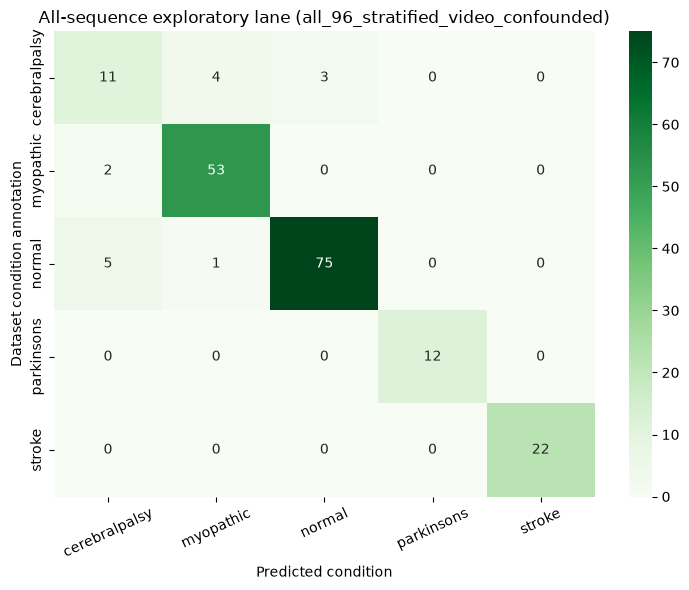

,sequence_id,video_id,true_condition,predicted_condition
20,cljas1yfs00fb3n6lna38ui6i,DlPDuHBAP7A,cerebralpalsy,myopathic
22,cljwslbss001w3n6lr5pf4t4k,SiYe89_WaTQ,cerebralpalsy,normal
32,cll8k24qs00583o6lbnpqmjyl,rWKYDfklSkE,cerebralpalsy,myopathic
34,cljwskeid001s3n6lrp3je2km,SiYe89_WaTQ,cerebralpalsy,normal
46,cllamxx59004k3o6lkg8cvmpl,zJ6PFxJrGf8,myopathic,cerebralpalsy
76,cljxhmxzx003s3n6lb888laay,hSIYGZhRGd4,normal,myopathic
96,cllc2jyqh003u3o6lmte5fdzt,MN4vnaNwIsA,normal,cerebralpalsy
111,clk7vlsxt00353n6lmynqknax,n-O8dHyYIF0,normal,cerebralpalsy
112,cljvwfmxb00293n6lyo0ffqwb,338R10fA_wU,cerebralpalsy,myopathic
113,cljo2y1f7001e3n6lt1wgacw6,3KnFt8bH3tE,normal,cerebralpalsy


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

all_sequence_confusion = confusion_matrix(
    labels[all_test_index],
    all_sequence_prediction,
    labels=CLASS_ORDER,
)
all_figure, all_axis = plt.subplots(figsize=(7.5, 6))
sns.heatmap(
    all_sequence_confusion,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=CLASS_ORDER,
    yticklabels=CLASS_ORDER,
    ax=all_axis,
)
all_axis.set_title(f"All-sequence exploratory lane ({all_split_name})")
all_axis.set_xlabel("Predicted condition")
all_axis.set_ylabel("Dataset condition annotation")
all_axis.tick_params(axis="x", labelrotation=25)
all_figure.tight_layout()
all_figure.savefig(
    ARTIFACT_DIR / "all_sequences_confusion_matrix.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()
all_error_table = pd.DataFrame({
    "sequence_id": sequence_ids[all_test_index],
    "video_id": video_ids[all_test_index],
    "true_condition": labels[all_test_index],
    "predicted_condition": all_sequence_prediction,
})
all_error_table = all_error_table[
    all_error_table["true_condition"]
    != all_error_table["predicted_condition"]
]
display(all_error_table)


## Lane A2: exact exp5-compatible split

This second lane deliberately selects the 68 sequence IDs used by exp5 so the split and score can be compared. The other 28 sequences remain in the all-sequence lane above. Real mode refuses to continue unless all 96 cached sequences and every one of the 68 exp5 IDs are present. Smoke mode uses a clearly labelled stratified demonstration because synthetic IDs cannot reproduce exp5.


In [16]:
id_to_index = {
    sequence_id: index
    for index, sequence_id in enumerate(sequence_ids)
}
if MODE == "real":
    missing = [item for item in EXP5_ORDER if item not in id_to_index]
    if missing:
        raise FileNotFoundError(
            f"Missing {len(missing)} exp5 pose sequences. "
            "Extract the full curated set in notebook 02."
        )
    train_ids, test_ids = exp5_exact_split(EXP5_ORDER)
    train_index = np.asarray([id_to_index[item] for item in train_ids])
    test_index = np.asarray([id_to_index[item] for item in test_ids])
    split_name = "exp5_exact_video_confounded"
    assert len(train_index) == 47 and len(test_index) == 21
else:
    from sklearn.model_selection import train_test_split
    all_index = np.arange(len(labels))
    train_index, test_index = train_test_split(
        all_index,
        train_size=0.70,
        random_state=42,
        stratify=labels,
    )
    train_ids = sequence_ids[train_index].tolist()
    test_ids = sequence_ids[test_index].tolist()
    split_name = "smoke_stratified_not_exp5"

five_class_model = make_rf()
five_class_model.fit(embeddings[train_index], labels[train_index])
five_class_prediction = five_class_model.predict(embeddings[test_index])
five_class_metrics = score_predictions(
    labels[test_index], five_class_prediction
)
exp5_missingness_model = make_rf()
exp5_missingness_model.fit(
    missingness_features[train_index], labels[train_index]
)
exp5_missingness_prediction = exp5_missingness_model.predict(
    missingness_features[test_index]
)
exp5_missingness_metrics = score_predictions(
    labels[test_index], exp5_missingness_prediction
)
print(split_name, five_class_metrics)
print("missingness-only audit:", exp5_missingness_metrics)
five_class_report = pd.DataFrame(classification_report(
    labels[test_index],
    five_class_prediction,
    labels=CLASS_ORDER,
    zero_division=0,
    output_dict=True,
)).T
display(five_class_report)


exp5_exact_video_confounded {'accuracy': 0.8571428571428571, 'balanced_accuracy': 0.8800000000000001, 'macro_f1': 0.8607142857142858}
missingness-only audit: {'accuracy': 0.3333333333333333, 'balanced_accuracy': 0.3638095238095238, 'macro_f1': 0.33606060606060606}


,precision,recall,f1-score,support
cerebralpalsy,1.000000,0.400000,0.571429,5.000000
myopathic,0.777778,1.000000,0.875000,7.000000
normal,0.750000,1.000000,0.857143,3.000000
parkinsons,1.000000,1.000000,1.000000,3.000000
stroke,1.000000,1.000000,1.000000,3.000000
accuracy,0.857143,0.857143,0.857143,0.857143
macro avg,0.905556,0.880000,0.860714,21.000000
weighted avg,0.890212,0.857143,0.835884,21.000000


## Expose source-video overlap and representation-training exposure

A sequence-level split is not independent when train and test rows come from the same source upload. The revised audit is stricter: it also intersects every classifier test set with **all** sequence IDs used in the progressive representation curriculum. Because the later group loss used condition annotations, overlap means both sample exposure and label-informed representation exposure.


In [17]:
representation_training_ids = set(checkpoint["sequence_ids"])


def leakage_row(name, fit_index, held_out_index):
    fit_videos = set(video_ids[fit_index])
    held_out_videos = set(video_ids[held_out_index])
    overlap = sorted(fit_videos & held_out_videos)
    representation_overlap = sorted(
        set(sequence_ids[held_out_index]) & representation_training_ids
    )
    return {
        "mode": MODE,
        "split": name,
        "train_sequences": len(fit_index),
        "test_sequences": len(held_out_index),
        "train_videos": len(fit_videos),
        "test_videos": len(held_out_videos),
        "shared_train_test_videos": len(overlap),
        "test_sequences_seen_in_representation_training": len(representation_overlap),
        "representation_training_was_label_aware": bool(
            checkpoint.get("label_aware_after_stage0", False)
        ),
    }, overlap


all_leakage, all_shared_videos = leakage_row(
    all_split_name, all_train_index, all_test_index
)
exp5_leakage, shared_videos = leakage_row(
    split_name, train_index, test_index
)
leakage_audit = pd.DataFrame([all_leakage, exp5_leakage])
display(leakage_audit)
print("all-sequence shared videos:", all_shared_videos)
print("exp5-compatible shared videos:", shared_videos)
if leakage_audit["test_sequences_seen_in_representation_training"].gt(0).any():
    print(
        "TRANSDUCTIVE WARNING: classifier test rows were used by the staged encoder. "
        "Treat every score below as a within-corpus descriptive readout."
    )
if MODE == "real":
    train_videos = set(video_ids[train_index])
    test_videos = set(video_ids[test_index])
    assert len(shared_videos) == 9
    assert set(test_videos).issubset(train_videos)


,mode,split,train_sequences,test_sequences,train_videos,test_videos,shared_train_test_videos,test_sequences_seen_in_representation_training,representation_training_was_label_aware
0,real,all_96_stratified_video_confounded,438,188,88,69,64,188,True
1,real,exp5_exact_video_confounded,47,21,12,9,9,21,True


all-sequence shared videos: [np.str_('-0wbleNgAwg'), np.str_('-oJM2wUUjws'), np.str_('338R10fA_wU'), np.str_('3FXUw98rrUY'), np.str_('3KnFt8bH3tE'), np.str_('5gpoegYv1hs'), np.str_('5qM6wxZ_dNs'), np.str_('7Ft1bUTzxkM'), np.str_('8PPLTf0fZsY'), np.str_('8mTHlAIdea0'), np.str_('9qg-3smwLcs'), np.str_('A2-NkglbQu0'), np.str_('B5hrxKe2nP8'), np.str_('CMls0LwK5OU'), np.str_('DlPDuHBAP7A'), np.str_('EHx08gSNfxQ'), np.str_('EHymg4AGMJs'), np.str_('Exqj0M000S8'), np.str_('FTHc-TJOQ34'), np.str_('HDkWDe6FZDg'), np.str_('Ha9LKXZfWBQ'), np.str_('IdAdpZaTWjU'), np.str_('KnvYRnTA3XQ'), np.str_('LIF-guVFEt0'), np.str_('MN4vnaNwIsA'), np.str_('R8LRCiTvUz8'), np.str_('RMdC8Pa3VbU'), np.str_('Rx21leooiqQ'), np.str_('SiYe89_WaTQ'), np.str_('USurcA3YKDY'), np.str_('Uj89KJwLYOY'), np.str_('VL0AOiZt_lg'), np.str_('Z_SEzAFi6-s'), np.str_('_Wn9oYGpRdM'), np.str_('b0KrA_96Ks0'), np.str_('bmi1hYOnTHs'), np.str_('dXAvAA556gE'), np.str_('diCVwltkV5M'), np.str_('dvfeYnWVD08'), np.str_('eBvzFkcvScg'), np.str_('eC

## Five-class confusion matrix

Keep a stable row and column order so the plot can be compared with exp5.


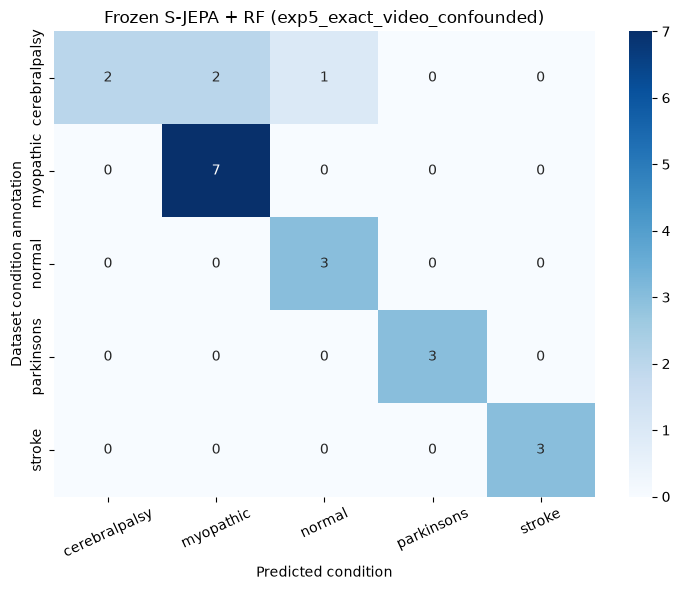

,sequence_id,video_id,true_condition,predicted_condition
6,cljas5esv00fn3n6lewd5xqdl,DlPDuHBAP7A,cerebralpalsy,myopathic
11,cljar9t8o00c83n6ltculhoct,wRntYsztIEY,cerebralpalsy,normal
15,cljas134500f73n6lkfbjfayp,DlPDuHBAP7A,cerebralpalsy,myopathic


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

five_class_confusion = confusion_matrix(
    labels[test_index],
    five_class_prediction,
    labels=CLASS_ORDER,
)
confusion_figure, confusion_axis = plt.subplots(figsize=(7.5, 6))
sns.heatmap(
    five_class_confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_ORDER,
    yticklabels=CLASS_ORDER,
    ax=confusion_axis,
)
confusion_axis.set_title(f"Frozen S-JEPA + RF ({split_name})")
confusion_axis.set_xlabel("Predicted condition")
confusion_axis.set_ylabel("Dataset condition annotation")
confusion_axis.tick_params(axis="x", labelrotation=25)
confusion_figure.tight_layout()
confusion_figure.savefig(
    ARTIFACT_DIR / "five_class_confusion_matrix.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()
error_table = pd.DataFrame({
    "sequence_id": sequence_ids[test_index],
    "video_id": video_ids[test_index],
    "true_condition": labels[test_index],
    "predicted_condition": five_class_prediction,
})
error_table = error_table[
    error_table["true_condition"] != error_table["predicted_condition"]
]
display(error_table)


## Four one-versus-normal classifiers

Each binary model uses the same all-sequence train and test IDs as Lane A1. The class filter is applied only after the global split. This uses all available condition-folder rows without selecting an easier split for one condition.


In [19]:
binary_rows = []
binary_models = {}
for condition in [c for c in CONDITIONS if c != "normal"]:
    train_keep = np.isin(
        labels[all_train_index], ["normal", condition]
    )
    test_keep = np.isin(
        labels[all_test_index], ["normal", condition]
    )
    binary_train = all_train_index[train_keep]
    binary_test = all_test_index[test_keep]
    classifier = make_rf()
    classifier.fit(
        embeddings[binary_train],
        labels[binary_train],
    )
    prediction = classifier.predict(embeddings[binary_test])
    metrics = score_predictions(labels[binary_test], prediction)
    probabilities = classifier.predict_proba(embeddings[binary_test])
    class_names = classifier.named_steps["rf"].classes_.tolist()
    auc = float("nan")
    if set(labels[binary_test]) == {"normal", condition}:
        condition_column = class_names.index(condition)
        y_binary = (labels[binary_test] == condition).astype(int)
        auc = roc_auc_score(
            y_binary, probabilities[:, condition_column]
        )
    binary_rows.append({
        "task": "one_vs_normal",
        "condition_vs_normal": condition,
        "train_sequences": len(binary_train),
        "test_sequences": len(binary_test),
        **metrics,
        "roc_auc": auc,
        "mode": MODE,
        "split": all_split_name,
    })
    binary_models[condition] = classifier

binary_metrics = pd.DataFrame(binary_rows)
display(binary_metrics)


,task,condition_vs_normal,train_sequences,test_sequences,accuracy,balanced_accuracy,macro_f1,roc_auc,mode,split
0,one_vs_normal,parkinsons,218,93,1.000000,1.000000,1.000000,1.000000,real,all_96_stratified_video_confounded
1,one_vs_normal,stroke,241,103,1.000000,1.000000,1.000000,1.000000,real,all_96_stratified_video_confounded
2,one_vs_normal,myopathic,317,136,0.985294,0.984736,0.984736,0.999551,real,all_96_stratified_video_confounded
3,one_vs_normal,cerebralpalsy,229,99,0.909091,0.858025,0.850428,0.898491,real,all_96_stratified_video_confounded


## Lane B / Lane C: why grouped Random Forests are still not enough

The minimum data requirement is at least two independent source videos in every class. The canonical normal class has one, so a valid five-class source-disjoint fold is blocked.

There is also a model-training requirement: the **entire five-stage curriculum** must run again inside each outer training fold, excluding held-out videos from Stage 0, every progressive stage, VICReg, and the label-aware group loss. Grouping only the Random Forest while reusing the final full-corpus encoder still leaks representation and label information.

The optional augmentation cohort adds normal videos and permits grouped classifier code to run, but the default final encoder still saw the held-out curriculum rows. Its grouped numbers are therefore descriptive stress tests, not leakage-resistant estimates. This notebook reports the exposure count beside them and does not call them honest generalization.


In [20]:
# ---------------------------------------------------------------------------
# Three reference lines (printed on EVERY run, whatever the augmentation flag).
#
# Read every descriptive number beside its three reference lines and the
# representation-exposure audit.
# baselines beside it. This block computes and prints them unconditionally --
# before the flag branch below -- so that whether Lane C is BLOCKED (flag off,
# the default) or actually runs (flag on), the reader always sees:
#
#   1. majority-class floor       -- five-class, computed live from `labels`
#                                    (myopathic 47/96 ~= 0.49). Beating this is
#                                    the weakest possible bar.
#   2. missingness-only RF floor  -- a RandomForest given ONLY per-joint and
#                                    per-frame pose-visibility fractions (no
#                                    gait geometry at all; see the cell above
#                                    and `pose_missingness_features.csv`). If a
#                                    latent model cannot clear this, it is
#                                    exploiting detector-failure shortcuts, not
#                                    reading gait. ~0.45 on the all-96 split.
#   3. 82-feature handcrafted RF  -- the exp5 saved result, 0.762 acc / 0.728
#                                    macro-F1 on its exact 47/21 split. This is
#                                    video-CONFOUNDED (optimistic), so it is a
#                                    ceiling-to-approach, not an honest target.
#
# Constants below are the literal exp5 numbers; cell-033's `comparison` frame
# is their single source of truth but is defined AFTER this cell, so they are
# duplicated here as named constants. Keep the two in sync.
# ---------------------------------------------------------------------------
HANDCRAFTED_EXP5_ACCURACY = 0.7619047619047619   # exp5 82-feat RF, mirrors cell-033
HANDCRAFTED_EXP5_MACRO_F1 = 0.7283333333333333   # exp5 82-feat RF, mirrors cell-033

five_class_majority = float(pd.Series(labels).value_counts(normalize=True).max())
print("REFERENCE LINES (descriptive readouts; encoder exposure is audited below):")
print(
    f"  1. majority-class (five-class, from labels)        "
    f"acc = {five_class_majority:.3f}"
)
print("  2. missingness-only RF (pose-visibility ONLY, a shortcut floor):")
print(
    f"       all-96 stratified split   "
    f"acc = {all_missingness_metrics['accuracy']:.3f}  "
    f"macro-F1 = {all_missingness_metrics['macro_f1']:.3f}"
)
print(
    f"       exp5 exact 47/21 split    "
    f"acc = {exp5_missingness_metrics['accuracy']:.3f}  "
    f"macro-F1 = {exp5_missingness_metrics['macro_f1']:.3f}"
)
print(
    f"  3. 82-feature handcrafted RF (exp5, video-CONFOUNDED ceiling)  "
    f"acc = {HANDCRAFTED_EXP5_ACCURACY:.3f}  "
    f"macro-F1 = {HANDCRAFTED_EXP5_MACRO_F1:.3f}"
)
print("  staged S-JEPA readouts below are transductive and label-informed:")
print(
    f"       all-96 stratified   "
    f"acc = {all_sequence_metrics['accuracy']:.3f}  "
    f"macro-F1 = {all_sequence_metrics['macro_f1']:.3f}"
)
print(
    f"       exp5 exact 47/21    "
    f"acc = {five_class_metrics['accuracy']:.3f}  "
    f"macro-F1 = {five_class_metrics['macro_f1']:.3f}"
)
print()

video_census = (
    pd.DataFrame({"condition": labels, "video_id": video_ids})
    .groupby("condition")["video_id"]
    .nunique()
    .reindex(CONDITIONS)
)
display(video_census.rename("unique_videos").to_frame())

grouped_metrics = None
if not INCLUDE_AUGMENTED_NORMAL:
    # Canonical corpus: normal has a single source video, so a five-class
    # video-disjoint fold cannot keep normal on both sides. Unchanged.
    if int(video_census.min()) < 2:
        print(
            "BLOCKED: five-class video-disjoint evaluation needs at least "
            "two source videos in every class."
        )
    else:
        print(
            "NOT RUN: pretrain a fresh S-JEPA target encoder inside each "
            "outer video-group fold before fitting its Random Forest."
        )
else:
    # ----------------------------------------------------------------------
    # Lane C: classifier-level video grouping enabled by the augmentation cohort.
    #
    # The self-annotated normal clips give the normal class many independent
    # source videos (was 1). That makes a *normal-vs-abnormal* grouped Random
    # Forest split possible for the first time. Entire videos are held out
    # from the classifier, but the saved encoder already saw all 159 rows.
    # We report grouped K-fold accuracy /
    # macro-F1 / ROC-AUC with bootstrap 95% CIs against explicit reference
    # lines. These grouped classifier splits remain TRANSDUCTIVE because the final
    # staged encoder saw the curriculum rows and condition annotations.
    #
    # Caveat kept visible: the augmentation normals carry auto-detected
    # (MediaPipe) bounding boxes, and only the normal class gained videos.
    # This is a descriptive stress test, not an independent-video result.
    # ----------------------------------------------------------------------
    from sklearn.model_selection import GroupKFold, StratifiedGroupKFold

    # Pool canonical (642) + augmentation-normal rows into one Lane C matrix.
    laneC_embeddings = np.concatenate([embeddings, aug_embeddings], axis=0)
    laneC_video_ids = np.concatenate([video_ids, aug_video_ids], axis=0)
    laneC_sequence_ids = np.concatenate([sequence_ids, aug_sequence_ids], axis=0)
    laneC_condition = np.concatenate([labels, aug_labels], axis=0)
    laneC_five_class_majority = float(
        pd.Series(laneC_condition).value_counts(normalize=True).max()
    )
    laneC_binary = np.where(laneC_condition == "normal", "normal", "abnormal")
    laneC_cohort = np.array(
        ["canonical"] * len(labels) + ["augmented_normal"] * len(aug_labels)
    )

    # Lane C video census (canonical + augmentation). This -- not the canonical
    # `video_census` above -- is what decides whether a per-class
    # video-disjoint fold is feasible, because the augmentation cohort adds
    # normal videos. The canonical census stays displayed above for provenance
    # and still drives the OFF-path BLOCKED message.
    laneC_video_census = (
        pd.DataFrame({"condition": laneC_condition, "video_id": laneC_video_ids})
        .groupby("condition")["video_id"]
        .nunique()
        .reindex(CONDITIONS)
    )

    normal_videos = sorted(set(laneC_video_ids[laneC_binary == "normal"]))
    abnormal_videos = sorted(set(laneC_video_ids[laneC_binary == "abnormal"]))
    print(
        f"Lane C corpus: {len(laneC_embeddings)} sequences | "
        f"normal videos={len(normal_videos)} "
        f"(canonical 1 + augmented {len(normal_videos) - 1}), "
        f"abnormal videos={len(abnormal_videos)}"
    )

    # The final curriculum encoder saw the progressive condition corpus and
    # its folder annotations before this classifier split. We surface the
    # exact overlap rather than treating a grouped Random Forest as independent.
    representation_seen = set(checkpoint.get("sequence_ids", []))

    def bootstrap_ci(values, iterations=2000, alpha=0.05):
        """Percentile bootstrap 95% CI over per-fold values (seeded)."""
        values = np.asarray(values, dtype=float)
        if len(values) == 0:
            return (float("nan"), float("nan"))
        rng = np.random.default_rng(42)
        means = [
            rng.choice(values, size=len(values), replace=True).mean()
            for _ in range(iterations)
        ]
        return (
            float(np.quantile(means, alpha / 2.0)),
            float(np.quantile(means, 1.0 - alpha / 2.0)),
        )

    def grouped_cv(
        feature_matrix, target, groups, positive_label=None,
        splitter=None, labels_order=None,
    ):
        """Classifier-level video-grouped CV with exposure auditing."""
        unique_groups = np.unique(groups)
        n_splits = min(5, len(unique_groups))
        if n_splits < 2:
            return None
        splitter = splitter or GroupKFold(n_splits=n_splits)
        fold_rows, representation_leaks = [], 0
        pooled_true, pooled_pred = [], []
        for train_idx, test_idx in splitter.split(
            feature_matrix, target, groups
        ):
            if len(set(target[train_idx])) < 2:
                # Degenerate fold (only one class in train); skip it.
                continue
            if labels_order is not None:
                missing_train = set(labels_order).difference(target[train_idx])
                missing_test = set(labels_order).difference(target[test_idx])
                if missing_train or missing_test:
                    raise RuntimeError(
                        "Grouped fold is missing required classes: "
                        f"train={sorted(missing_train)}, test={sorted(missing_test)}"
                    )
            clf = make_rf()
            clf.fit(feature_matrix[train_idx], target[train_idx])
            pred = clf.predict(feature_matrix[test_idx])
            row = score_predictions(target[test_idx], pred)
            if labels_order is not None:
                row["macro_f1"] = f1_score(
                    target[test_idx], pred, labels=labels_order,
                    average="macro", zero_division=0,
                )
            pooled_true.extend(target[test_idx].tolist())
            pooled_pred.extend(pred.tolist())
            if positive_label is not None and set(target[test_idx]) == set(
                np.unique(target)
            ):
                classes = clf.named_steps["rf"].classes_.tolist()
                proba = clf.predict_proba(feature_matrix[test_idx])
                y_bin = (target[test_idx] == positive_label).astype(int)
                row["roc_auc"] = roc_auc_score(
                    y_bin, proba[:, classes.index(positive_label)]
                )
            fold_rows.append(row)
            representation_leaks += len(
                set(laneC_sequence_ids[test_idx]) & representation_seen
            )
        pooled = score_predictions(np.asarray(pooled_true), np.asarray(pooled_pred))
        if labels_order is not None:
            pooled["macro_f1"] = f1_score(
                pooled_true, pooled_pred, labels=labels_order,
                average="macro", zero_division=0,
            )
        return {
            "folds": fold_rows, "pooled": pooled,
            "representation_leaks_across_folds": representation_leaks,
        }

    # -- Primary Lane C task: video-disjoint normal vs abnormal ------------
    binary_cv = grouped_cv(
        laneC_embeddings, laneC_binary, laneC_video_ids,
        positive_label="abnormal",
    )
    laneC_rows = []
    if binary_cv and binary_cv["folds"]:
        folds = pd.DataFrame(binary_cv["folds"])
        majority = pd.Series(laneC_binary).value_counts(normalize=True).max()
        summary = {
            "task": "normal_vs_abnormal_video_disjoint",
            "n_folds": len(folds),
            "n_sequences": len(laneC_embeddings),
            "normal_videos": len(normal_videos),
            "abnormal_videos": len(abnormal_videos),
        }
        for metric in ["accuracy", "balanced_accuracy", "macro_f1", "roc_auc"]:
            if metric in folds:
                lo, hi = bootstrap_ci(folds[metric].dropna().to_numpy())
                summary[f"{metric}_mean"] = float(folds[metric].mean())
                summary[f"{metric}_ci_low"] = lo
                summary[f"{metric}_ci_high"] = hi
        summary["majority_class_baseline"] = float(majority)
        summary["encoder"] = checkpoint_path.name
        summary["test_seqs_seen_in_representation_training"] = binary_cv[
            "representation_leaks_across_folds"
        ]
        laneC_rows.append(summary)
        print(
            f"\nnormal-vs-abnormal (video-disjoint, {summary['n_folds']} folds): "
            f"acc {summary.get('accuracy_mean', float('nan')):.3f} "
            f"[{summary.get('accuracy_ci_low', float('nan')):.3f}, "
            f"{summary.get('accuracy_ci_high', float('nan')):.3f}] | "
            f"macro-F1 {summary.get('macro_f1_mean', float('nan')):.3f} "
            f"[{summary.get('macro_f1_ci_low', float('nan')):.3f}, "
            f"{summary.get('macro_f1_ci_high', float('nan')):.3f}]"
        )
        # Reference lines, restated beside the descriptive Lane C number. This is a
        # BINARY task, so its majority floor differs from the five-class block
        # at the top of the cell; the missingness / handcrafted references are
        # five-class and are shown here for scale only.
        print(f"  reference 1: majority-class baseline (binary) = {majority:.3f}")
        print(
            "  reference 2: missingness-only RF (five-class shortcut floor) = "
            f"{all_missingness_metrics['accuracy']:.3f} acc (all-96); "
            f"{exp5_missingness_metrics['accuracy']:.3f} (exp5)"
        )
        print(
            "  reference 3: 82-feature handcrafted RF (five-class, "
            f"video-CONFOUNDED) = {HANDCRAFTED_EXP5_ACCURACY:.3f} acc"
        )
        print(
            "  reference: video-confounded all-96 lane accuracy = "
            f"{all_sequence_metrics['accuracy']:.3f} (optimistically biased)"
        )
        if summary["test_seqs_seen_in_representation_training"]:
            print(
                "  NOTE: "
                f"{summary['test_seqs_seen_in_representation_training']} held-out "
                "sequences were in progressive representation training. The final encoder saw condition annotations for curriculum rows. "
                "To obtain a generalization estimate, rerun all five stages "
                "inside each outer source-video training fold."
            )

    # -- Five-class grouped stress test -----------------------------------
    # Gate on the LANE C census, not the canonical `video_census`: the
    # augmentation cohort adds normal videos, so the count that decides whether
    # a five-class video-disjoint fold is feasible must include them.
    if int(laneC_video_census.min()) >= 2:
        # The smallest classes have only two source videos. Two stratified
        # group folds keep every class in both training and testing. The old
        # five-fold GroupKFold run produced one training fold with no
        # cerebral-palsy example and incomparable macro-F1 label sets.
        five_splitter = StratifiedGroupKFold(
            n_splits=2, shuffle=True, random_state=42
        )
        five_cv = grouped_cv(
            laneC_embeddings, laneC_condition, laneC_video_ids,
            splitter=five_splitter, labels_order=CONDITIONS,
        )
        if five_cv and five_cv["folds"]:
            f5 = pd.DataFrame(five_cv["folds"])
            row5 = {
                "task": "five_class_classifier_video_disjoint_encoder_transductive",
                "n_folds": len(f5),
                "n_sequences": len(laneC_embeddings),
                "encoder": checkpoint_path.name,
                "test_seqs_seen_in_representation_training": five_cv[
                    "representation_leaks_across_folds"
                ],
            }
            for metric in ["accuracy", "balanced_accuracy", "macro_f1"]:
                row5[f"{metric}_mean"] = float(f5[metric].mean())
                row5[f"{metric}_pooled_oof"] = float(five_cv["pooled"][metric])
            laneC_rows.append(row5)
            print(
                f"\nfive-class (classifier-video-disjoint, encoder-transductive; "
                f"CP/PD have only 2 videos, {row5['n_folds']} folds): "
                f"mean acc {row5['accuracy_mean']:.3f} | "
                f"mean macro-F1 {row5['macro_f1_mean']:.3f} | "
                f"pooled OOF macro-F1 {row5['macro_f1_pooled_oof']:.3f}"
            )
            # Use the actual 159-row Lane C class distribution here. The
            # canonical-only majority printed above is a different cohort.
            print(
                f"  reference 1: majority-class (five-class Lane C corpus) = "
                f"{laneC_five_class_majority:.3f}"
            )
            print(
                "  reference 2: missingness-only RF (five-class shortcut) = "
                f"{all_missingness_metrics['accuracy']:.3f} acc (all-96); "
                f"{exp5_missingness_metrics['accuracy']:.3f} (exp5)"
            )
            print(
                "  reference 3: 82-feature handcrafted RF (five-class, "
                f"video-CONFOUNDED) = {HANDCRAFTED_EXP5_ACCURACY:.3f} acc / "
                f"{HANDCRAFTED_EXP5_MACRO_F1:.3f} macro-F1"
            )
    else:
        print(
            "\nfive-class video-disjoint still BLOCKED: augmentation added "
            "normal videos only; "
            + ", ".join(
                f"{c}={int(laneC_video_census[c])}"
                for c in CONDITIONS
                if int(laneC_video_census[c]) < 2
            )
            + " still have <2 source videos."
        )

    grouped_metrics = pd.DataFrame(laneC_rows)
    if len(grouped_metrics):
        display(grouped_metrics)
        grouped_metrics.to_csv(
            ARTIFACT_DIR / "lane_c_video_disjoint_metrics.csv", index=False
        )
        print("\nsaved:", ARTIFACT_DIR / "lane_c_video_disjoint_metrics.csv")

REFERENCE LINES (descriptive readouts; encoder exposure is audited below):
  1. majority-class (five-class, from labels)        acc = 0.431
  2. missingness-only RF (pose-visibility ONLY, a shortcut floor):
       all-96 stratified split   acc = 0.441  macro-F1 = 0.355
       exp5 exact 47/21 split    acc = 0.333  macro-F1 = 0.336
  3. 82-feature handcrafted RF (exp5, video-CONFOUNDED ceiling)  acc = 0.762  macro-F1 = 0.728
  staged S-JEPA readouts below are transductive and label-informed:
       all-96 stratified   acc = 0.920  macro-F1 = 0.899
       exp5 exact 47/21    acc = 0.857  macro-F1 = 0.861



,unique_videos
condition,
normal,29
parkinsons,9
stroke,18
myopathic,28
cerebralpalsy,9


NOT RUN: pretrain a fresh S-JEPA target encoder inside each outer video-group fold before fitting its Random Forest.


## Compare with the checked exp5 result

The exp5 confusion matrix below was recovered from its saved notebook output. Rows and columns are cerebralpalsy, myopathic, normal, parkinsons, stroke.

\[
\begin{bmatrix}
3&1&0&1&0\\\\
0&7&0&0&0\\\\
0&0&3&0&0\\\\
1&0&0&2&0\\\\
1&1&0&0&1
\end{bmatrix}
\]


In [21]:
comparison = pd.DataFrame([
    {
        "system": "exp5 handcrafted 82-feature RF",
        "mode": "real saved result",
        "split": "exact 47/21, video-confounded",
        "accuracy": 0.7619047619047619,
        "macro_f1": 0.7283333333333333,
        "independent_video_test": False,
    },
    {
        "system": "frozen S-JEPA pooled latent RF",
        "mode": MODE,
        "split": split_name,
        "accuracy": five_class_metrics["accuracy"],
        "macro_f1": five_class_metrics["macro_f1"],
        "independent_video_test": False,
    },
    {
        "system": "frozen S-JEPA pooled latent RF, all rows",
        "mode": MODE,
        "split": all_split_name,
        "accuracy": all_sequence_metrics["accuracy"],
        "macro_f1": all_sequence_metrics["macro_f1"],
        "independent_video_test": False,
    },
])
display(comparison)
if MODE == "smoke":
    print(
        "The S-JEPA row is a synthetic code-path check and is not "
        "comparable with the real exp5 result."
    )


,system,mode,split,accuracy,macro_f1,independent_video_test
0,exp5 handcrafted 82-feature RF,real saved result,"exact 47/21, video-confounded",0.761905,0.728333,False
1,frozen S-JEPA pooled latent RF,real,exp5_exact_video_confounded,0.857143,0.860714,False
2,"frozen S-JEPA pooled latent RF, all rows",real,all_96_stratified_video_confounded,0.920213,0.898512,False


## Why the exp5 number is only a reference point

Local methodology review found:

- Every one of its 21 test sequences shares a source video with training.
- The split is not stratified or group-aware.
- Pose extraction ignores the GAVD bbox.
- FPS is hardcoded to 30 although source videos include other rates.
- Twenty-two stored features are all zero and FPS is another constant feature.
- Legacy temporal ankle logic uses COCO indices 15 and 16, which are wrists in BlazePose. Correct BlazePose ankle indices are 27 and 28.

These findings do not erase the baseline. They define what a fair comparison can and cannot claim.

This is a system-level comparison, not an isolated representation ablation. The S-JEPA lane uses bbox-aware MediaPipe poses while exp5 used a different extraction and handcrafted-feature pipeline. A score difference cannot be attributed to S-JEPA alone. A causal representation comparison would compute both feature sets from the same cached poses and use the same split.


## Save models and metrics

Results remain namespaced by smoke or real mode.


In [22]:
import hashlib
import joblib
import json

metric_rows = [
    {
        "task": "five_class_exp5_exact",
        "condition": "all",
        "mode": MODE,
        "split": split_name,
        **five_class_metrics,
    },
    {
        "task": "five_class_all_sequences",
        "condition": "all",
        "mode": MODE,
        "split": all_split_name,
        **all_sequence_metrics,
    },
]
metric_rows.extend(
    binary_metrics.rename(
        columns={"condition_vs_normal": "condition"}
    ).to_dict("records")
)
metrics_table = pd.DataFrame(metric_rows)
metrics_table.to_csv(
    ARTIFACT_DIR / "classifier_metrics.csv",
    index=False,
)
leakage_audit.to_csv(
    ARTIFACT_DIR / "leakage_audit.csv",
    index=False,
)
comparison.to_csv(
    ARTIFACT_DIR / "exp5_comparison.csv",
    index=False,
)
five_class_report.to_csv(
    ARTIFACT_DIR / "five_class_classification_report.csv"
)
all_sequence_report.to_csv(
    ARTIFACT_DIR / "all_sequences_classification_report.csv"
)
error_table.to_csv(
    ARTIFACT_DIR / "five_class_errors.csv", index=False
)
all_error_table.to_csv(
    ARTIFACT_DIR / "all_sequences_errors.csv", index=False
)
pd.DataFrame(
    five_class_confusion,
    index=CLASS_ORDER,
    columns=CLASS_ORDER,
).to_csv(ARTIFACT_DIR / "five_class_confusion_matrix.csv")
pd.DataFrame(
    all_sequence_confusion,
    index=CLASS_ORDER,
    columns=CLASS_ORDER,
).to_csv(ARTIFACT_DIR / "all_sequences_confusion_matrix.csv")
missingness_audit = pd.DataFrame([
    {
        "lane": "all_sequences",
        "split": all_split_name,
        **all_missingness_metrics,
    },
    {
        "lane": "exp5_exact",
        "split": split_name,
        **exp5_missingness_metrics,
    },
])
missingness_audit.to_csv(
    ARTIFACT_DIR / "missingness_only_classifier_metrics.csv",
    index=False,
)
embedding_hasher = hashlib.sha256()
for sequence_id, embedding in sorted(
    zip(sequence_ids, embeddings), key=lambda item: item[0]
):
    embedding_hasher.update(str(sequence_id).encode("utf-8"))
    embedding_hasher.update(
        np.ascontiguousarray(embedding).tobytes()
    )
binary_row_contract = {}
for condition in [c for c in CONDITIONS if c != "normal"]:
    binary_row_contract[condition] = {
        "train_sequence_ids": sequence_ids[
            all_train_index[
                np.isin(
                    labels[all_train_index], ["normal", condition]
                )
            ]
        ].tolist(),
        "test_sequence_ids": sequence_ids[
            all_test_index[
                np.isin(
                    labels[all_test_index], ["normal", condition]
                )
            ]
        ].tolist(),
    }
model_contract = {
    "mode": MODE,
    "splits": {
        "all_sequences": all_split_name,
        "exp5_exact": split_name,
    },
    "checkpoint_fingerprint": checkpoint["dataset_fingerprint"],
    "checkpoint_parent_fingerprint": checkpoint.get("parent_fingerprint"),
    "curriculum_complete": checkpoint.get("curriculum_complete", False),
    "conditions_seen": checkpoint.get("conditions_seen"),
    "completed_stages": checkpoint.get("completed_stages"),
    "loss_config": checkpoint.get("loss_config"),
    "label_aware_after_stage0": checkpoint.get("label_aware_after_stage0", False),
    "embedding_corpus_sha256": embedding_hasher.hexdigest(),
    "mask_keypoints": MASK_KEYPOINTS,
    "feature_count": len(feature_columns),
    "class_order": CLASS_ORDER,
    "exp5_exact_train_sequence_ids": list(train_ids),
    "exp5_exact_test_sequence_ids": list(test_ids),
    "all_sequences_train_sequence_ids": all_train_ids,
    "all_sequences_test_sequence_ids": all_test_ids,
    "binary_row_contract": binary_row_contract,
    "include_augmented_normal": bool(INCLUDE_AUGMENTED_NORMAL),
    "augmented_normal_sequences": int(len(aug_sequence_ids)),
    "augmented_normal_videos": int(len(set(aug_video_ids.tolist()))),
    "encoder_checkpoint": checkpoint_path.name,
}
(ARTIFACT_DIR / "classifier_contract.json").write_text(
    json.dumps(model_contract, indent=2) + "\n",
    encoding="utf-8",
)
joblib.dump(
    five_class_model,
    ARTIFACT_DIR / "five_class_exp5_exact_random_forest.joblib",
)
joblib.dump(
    all_sequence_model,
    ARTIFACT_DIR / "five_class_all_sequences_random_forest.joblib",
)
joblib.dump(
    all_missingness_model,
    ARTIFACT_DIR / "all_sequences_missingness_audit.joblib",
)
joblib.dump(
    exp5_missingness_model,
    ARTIFACT_DIR / "exp5_exact_missingness_audit.joblib",
)
for condition, classifier in binary_models.items():
    joblib.dump(
        classifier,
        ARTIFACT_DIR / f"{condition}_vs_normal_random_forest.joblib",
    )
# Lane C grouped, video-disjoint metrics are written alongside their own CSV
# inside cell-031 (lane_c_video_disjoint_metrics.csv). Surface a pointer here
# so the saved-artifact log is complete when the augmentation cohort is on.
if INCLUDE_AUGMENTED_NORMAL and grouped_metrics is not None and len(grouped_metrics):
    print(
        "Lane C video-disjoint metrics saved to "
        f"{ARTIFACT_DIR / 'lane_c_video_disjoint_metrics.csv'}"
    )
print("saved capstone artifacts under", ARTIFACT_DIR)


saved capstone artifacts under /Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/work/artifacts/real


## Capstone conclusion template

Report:

1. Final curriculum checkpoint fingerprint, parent fingerprint, completed stages, and label-aware status.
2. The exact 12-keypoint whitelist and mapping-file hash.
3. Number of sequences and independent source videos per condition.
4. Classifier split, train-test video overlap, and the number of test rows seen during representation training.
5. JEPA/VICReg/group-loss diagnostics, centroid geometry, and normal-anchor drift from notebooks 04–05.
6. Five-class and binary readout metrics, missingness-only controls, and confusion patterns:explicitly labeled descriptive when exposure is nonzero.
7. A statement that folder labels are dataset annotations and the work is exploratory and non-diagnostic.

Do not reuse the legacy 61.9% normal-only/10-keypoint result as evidence for this revised model. Do not claim unseen-video or patient generalization until the complete curriculum is trained inside source-disjoint outer folds. With only one canonical normal source video, the five-class estimate remains blocked.
